# **Forecast-Driven Vehicle Routing for Bike-Share Rebalancing**

---

<br>

## **A Hybrid Search + Learning Approach - Citi Bike Network (Jersey City & Hoboken Areas)**

<br>

Implementing a hybrid AI system combining **Machine Learning (Demand Forecasting)** and **Search/optimization (Rebalancing Route Planning)** to address bike-share station imbalance.

# **Section 1: Setup & Data Loading**<br>

Starting by importing the libraries needed for the implementation, then loading the raw Citi Bike trip data for the cities I'm working with, and doing an initial inspection to confirm the data looks as expected before any processing begins.

In [1229]:
# Importing the core libraries needed as of now.

import pandas as pd # For working with tabular data (rows/columns, for the csv spreadsheet/s).
import numpy as np # For numerical operations.
import glob # For finding files that match a pattern (ex: all "JC-*" files).
import json # For saving/loading small structured data, like the station list later.
import os # For file path utilities (ex: extracting just the filename from a full path).
import matplotlib.pyplot as plt # Standard plotting library, used later for charts.
import seaborn as sns # Used to built statistical charts, on matplotlib.
import requests # For sending HTTP requests to download data (for Dataset fetching from Github).
from io import StringIO # For converting standard string text into an in-memory stream that acts exactly like a physical file (For Dataset fetching from Github.

pd.set_option("display.max_columns", None) # Always show all columns when previewing a dataframe.
sns.set_style("whitegrid") # Consistent, clean chart style for later visualizations.

**Loading the raw dataset found:**

Now I'm loading all Jersey City (JC-) Citi Bike trip files found in the dataset folder. I have saved the datasets in my GitHub repository (covering the period from January 2025 to June 2026) and configured the notebook to fetch the data directly from there. I have also structured this section to allow manual selection of the start and end months of the datasets used for analysis. This approach provides flexibility for future analyses, as different amounts of data can be selected and utilized depending on the specific requirements. I'm also using a wildcard pattern here (rather than a single hardcoded filename), so that I can later re-run on additional months simply by adding more month based dataset files to the same folder.<br><br>

Real Dataset Found on: [Click Here to Access Citi Bike Trip Data](https://s3.amazonaws.com/tripdata/index.html)

<br>

My Stored Dataset Link: [Click Here to View on My GitHub](https://github.com/thuvaragan20251067/Foundations-of-Artificial-Intelligence/tree/main/CitiBike-Dataset)

<br>

Months Covered in my Stored Dataset Folder: **January 2025 - June 2026** (Last 18 Months)

<br>

Months I Used for the Study below: **January 2026 - June 2026** (Last 6 Months)

<br>

**NOTE:**<br>This can be altered by adding more/ less real data from the actual dataset set link, to my stored folder in github repo, and also by adjusting the start and end month needed in the study as mentioned below.<br>
Therefore I can test any amount of data as per the needs.

In [1230]:
# For the Citi Bike Dataset fetching from my Github Repo that the data sits in.
# Each month file has been stored seperately - from January 2025 to June 2026.

# GitHub Dataset Configuration.
GITHUB_USERNAME = "thuvaragan20251067"
GITHUB_REPO = "Foundations-of-Artificial-Intelligence"
GITHUB_BRANCH = "main"
DATASET_FOLDER = "CitiBike-Dataset"

# Selecting the period I want to use for this analysis (Using only the first 6 months of 2026).
# In YYYYMM format.
START_MONTH = "202601"
END_MONTH   = "202606"

# Finding the relevant dataset files from my GitHub.
github_raw_path = (
    f"https://raw.githubusercontent.com/"
    f"{GITHUB_USERNAME}/"
    f"{GITHUB_REPO}/"
    f"{GITHUB_BRANCH}/"
    f"{DATASET_FOLDER}/")

# Generating the required months.
selected_months = pd.period_range(start=pd.Period(START_MONTH, freq="M"),
                                  end=pd.Period(END_MONTH, freq="M"),
                                  freq="M")

selected_months = [
    str(month).replace("-", "")
    for month in selected_months]

print(f"Months selected: {selected_months}\n")

# Loading the selected CSV files.
dataframes = []

for month in selected_months:
  filename = f"JC-{month}-citibike-tripdata.csv"
  file_url = github_raw_path + filename
  print("Loading:", filename)
  response = requests.get(file_url)

  if response.status_code == 200:
    temp_dataframe = pd.read_csv(StringIO(response.text))
    temp_dataframe["source_file"] = filename
    dataframes.append(temp_dataframe)
  else:
    print(f"WARNING: {filename} not found")

# Combining all the retrieved months.
if not dataframes:
  raise ValueError("No dataset files were successfully loaded! Please check whether the GITHUB_USERNAME, GITHUB_REPO, GITHUB_BRANCH, and DATASET_FOLDER are correct, and that the repo is public.")

raw_dataframe = pd.concat(dataframes, ignore_index=True)

# Removing duplicate trips, in case any "ride_id" appears more than once across the fetched files.
rows_before_duplicates = len(raw_dataframe)
raw_dataframe = raw_dataframe.drop_duplicates(subset="ride_id",keep="first")
print(f"\nDuplicate trips removed: {rows_before_duplicates - len(raw_dataframe)}")

# Converting timestamps.
raw_dataframe["started_at"] = pd.to_datetime(raw_dataframe["started_at"])
raw_dataframe["ended_at"] = pd.to_datetime(raw_dataframe["ended_at"])
print(f"\nTotal trips loaded: {len(raw_dataframe)}\n")
raw_dataframe.head(10)

Months selected: ['202601', '202602', '202603', '202604', '202605', '202606']

Loading: JC-202601-citibike-tripdata.csv
Loading: JC-202602-citibike-tripdata.csv
Loading: JC-202603-citibike-tripdata.csv
Loading: JC-202604-citibike-tripdata.csv
Loading: JC-202605-citibike-tripdata.csv
Loading: JC-202606-citibike-tripdata.csv

Duplicate trips removed: 18

Total trips loaded: 415721



,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,source_file
0,40FBC7AEEBB220EC,electric_bike,2026-01-11 15:01:01.954,2026-01-11 15:16:57.103,14 St Ferry - 14 St & Shipyard Ln,HB202,Pier 61 at Chelsea Piers,6233.04,40.752961,-74.024353,40.746872,-74.00821,member,JC-202601-citibike-tripdata.csv
1,47FB1CA65D3F7E0F,electric_bike,2026-01-16 11:49:41.364,2026-01-16 11:58:27.291,14 St Ferry - 14 St & Shipyard Ln,HB202,Madison St & 1 St,HB402,40.752961,-74.024353,40.738790,-74.03930,member,JC-202601-citibike-tripdata.csv
2,BFB10DE1E40F3709,electric_bike,2026-01-07 19:55:41.424,2026-01-07 19:59:09.874,Church Sq Park - 5 St & Park Ave,HB601,Madison St & 1 St,HB402,40.742659,-74.032233,40.738790,-74.03930,member,JC-202601-citibike-tripdata.csv
3,F16B896495AAF618,electric_bike,2026-01-24 11:12:10.547,2026-01-24 11:34:42.801,Madison St & 1 St,HB402,Madison St & 1 St,HB402,40.738790,-74.039300,40.738790,-74.03930,member,JC-202601-citibike-tripdata.csv
4,76D77D5F1D491B3C,electric_bike,2026-01-22 20:58:00.602,2026-01-22 21:02:39.088,Clinton St & 7 St,HB303,Madison St & 1 St,HB402,40.745420,-74.033320,40.738790,-74.03930,casual,JC-202601-citibike-tripdata.csv
5,2FD7944F6F11A694,classic_bike,2026-01-03 09:05:49.612,2026-01-03 09:16:02.970,Bloomfield St & 15 St,HB203,Madison St & 1 St,HB402,40.754530,-74.026580,40.738790,-74.03930,member,JC-202601-citibike-tripdata.csv
6,AACDDEAD684B8154,electric_bike,2026-01-21 18:31:02.073,2026-01-21 18:34:27.265,Clinton St & 7 St,HB303,Madison St & 1 St,HB402,40.745420,-74.033320,40.738790,-74.03930,member,JC-202601-citibike-tripdata.csv
7,A2DB87D89A2E8265,classic_bike,2026-01-21 11:37:26.754,2026-01-21 11:45:12.007,Clinton St & 7 St,HB303,Madison St & 1 St,HB402,40.745420,-74.033320,40.738790,-74.03930,member,JC-202601-citibike-tripdata.csv
8,69B811F9ED8082AF,classic_bike,2026-01-05 22:54:39.799,2026-01-05 22:59:34.400,River St & 1 St,HB609,Madison St & 1 St,HB402,40.737215,-74.028865,40.738790,-74.03930,member,JC-202601-citibike-tripdata.csv
9,5CD15A5C385A717D,electric_bike,2026-01-02 16:20:31.056,2026-01-02 16:27:09.161,River St & 1 St,HB609,Madison St & 1 St,HB402,40.737215,-74.028865,40.738790,-74.03930,member,JC-202601-citibike-tripdata.csv


**Initial inspection:**

Before doing anything else, I'm checking the shape of the data, the date range it covers, how many unique stations are present, and whether there are any missing values that will need to be handled.

In [1231]:
# Checking the overall shape (how many rows (trips) and columns there are, across all files combined).
print(f"Shape (all months based dataset files combined): {raw_dataframe.shape}\n")

# Building one summary row per source file, instead of printing a separate block for each one.
# This scales cleanly even if many more months get added later, and is easier to read than a long stack of print statements.
file_summary_rows = []
for source_filename, file_group in raw_dataframe.groupby("source_file"):
  missing_counts = file_group.isnull().sum()
  file_summary_rows.append({
      "Source File": source_filename,
      "Rows": len(file_group),
      "Date Range Start": file_group["started_at"].min(),
      "Date Range End": file_group["started_at"].max(),
      "Unique Start Stations": file_group["start_station_name"].nunique(),
      "Unique End Stations": file_group["end_station_name"].nunique(),
      "Rows with Missing Values": missing_counts[missing_counts > 0].sum(),})

file_summary_table = pd.DataFrame(file_summary_rows)

styled_file_summary = (
    file_summary_table.style
    .format({"Date Range Start": "{:%Y-%m-%d %H:%M}", "Date Range End": "{:%Y-%m-%d %H:%M}"})
    .set_caption("Data File Inspection Summary")
    .hide(axis="index"))

display(styled_file_summary)

Shape (all months based dataset files combined): (415721, 14)



Source File,Rows,Date Range Start,Date Range End,Unique Start Stations,Unique End Stations,Rows with Missing Values
JC-202601-citibike-tripdata.csv,40044,2025-12-31 11:40,2026-01-31 23:47,106,157,2978
JC-202602-citibike-tripdata.csv,25809,2026-01-31 20:30,2026-02-28 23:53,105,136,1543
JC-202603-citibike-tripdata.csv,62367,2026-02-28 16:00,2026-03-31 23:46,107,179,1594
JC-202604-citibike-tripdata.csv,82272,2026-04-01 00:04,2026-04-30 23:59,108,216,1665
JC-202605-citibike-tripdata.csv,95332,2026-05-01 00:01,2026-05-31 23:53,108,224,1358
JC-202606-citibike-tripdata.csv,109897,2026-05-31 21:00,2026-06-30 23:55,106,251,1511


# **Section 2: Data Cleaning & Scoping**<br>

Now I'm trimming the loaded data down to a clean, well-defined scope:<br>
Exact calendar month(s) only, no rows with missing station information, and a manageable set of the highest-traffic stations to model.

**Trimming to clean calendar month(s):**

Each data file can contain a small number of trips from the boundary of the previous or next month (ex: the January 2026 dataset file also had a few trips from 31 Dec 2025). So this is to detect which month(s) actually make up the bulk of the data (more than 1% of all rows), and trim everything else out, so the final dataset only covers full, clean calendar month(s).

In [1232]:
# Checking how many rows belong to each calendar month present in the data.
month_counts = raw_dataframe["started_at"].dt.to_period("M").value_counts()

month_counts_table = month_counts.reset_index()
month_counts_table.columns = ["Month", "Row Count"]
month_counts_table["Month"] = month_counts_table["Month"].astype(str)

display(month_counts_table.style.set_caption("Row Counts by Calendar Month Found in the Data").hide(axis="index"))

# Treating a month as "real" only if it makes up more than 1% of all rows.
# This filters out stray boundary trips instead of pulling in a whole extra month for them.
MONTH_THRESHOLD = 0.01 * len(raw_dataframe)
real_months = month_counts[month_counts > MONTH_THRESHOLD].index
print(f"\nMonth(s) treated as 'real' (more than 1% of rows): {sorted(real_months.astype(str))}\n")

# Cleaning up the exact start and end timestamp of the clean calendar window to keep.
month_start = min(m.start_time for m in real_months)
month_end = max(m.end_time for m in real_months).replace(hour=23, minute=59, second=59)

# Trimming raw_dataframe down to just that clean calendar window.
rows_before_trim = len(raw_dataframe)
trimmed_dataframe = raw_dataframe[(raw_dataframe["started_at"] >= month_start) & (raw_dataframe["started_at"] <= month_end)].copy()
print(f"Trimmed to calendar window: [{month_start} to {month_end}]", "\n")
print(f"Rows before trim : {rows_before_trim}"
      f"\nRows after trim  : {len(trimmed_dataframe)}"
      f"\nRows dropped     : {rows_before_trim - len(trimmed_dataframe)} (stray boundary trips)")

print("\nNOTE: Rows = Trips")

Month,Row Count
2026-06,109888
2026-05,95341
2026-04,82272
2026-03,62362
2026-01,40037
2026-02,25808
2025-12,13



Month(s) treated as 'real' (more than 1% of rows): ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05', '2026-06']

Trimmed to calendar window: [2026-01-01 00:00:00 to 2026-06-30 23:59:59.999999999] 

Rows before trim : 415721
Rows after trim  : 415708
Rows dropped     : 13 (stray boundary trips)

NOTE: Rows = Trips


**Handling missing station data:**

A small number of trips are missing a start or end station name (ex: due to a bike not being docked properly). Since station identity is essential for this project (everything is grouped by station), these rows are dropped rather than guessed at, for a cleaner set of data usage.

In [1233]:
# Dropping rows where the start or end station name is missing.
# This is done for an even cleaner data, that'll help with the learning part.
rows_before_dropping_missing_values = len(trimmed_dataframe)
trimmed_dataframe = trimmed_dataframe.dropna(subset=["start_station_name", "end_station_name"])

print(f"Rows before dropping missing station info : {rows_before_dropping_missing_values}")
print(f"Rows after dropping missing station info  : {len(trimmed_dataframe)} (dropped {rows_before_dropping_missing_values - len(trimmed_dataframe)} rows of trips)")

print("\nNOTE: Rows = Trips")

Rows before dropping missing station info : 415708
Rows after dropping missing station info  : 413602 (dropped 2106 rows of trips)

NOTE: Rows = Trips


**Selecting the top-traffic stations:**

To keep the problem instance manageable and interpretable, this project focuses on the highest-traffic stations only, rather than the full network. The top stations are selected automatically based on trip volume.
This step works unchanged if more months are added later for testing.<br><br>
I have calculated the top stations based on departure / arrival / (departure + arrival).

In [1234]:
# Selecting the top N stations by how many trips start there (departure volume).
N_TOP_STATIONS = 20 # Selecting top 20 only.
top_stations_departures = trimmed_dataframe["start_station_name"].value_counts().head(N_TOP_STATIONS).index.tolist()

print(f"Top {N_TOP_STATIONS} stations selected (based on bike depature volume):")
for s in top_stations_departures:
  print(" -", s)

Top 20 stations selected (based on bike depature volume):
 - Grove St PATH
 - River St & Newark St
 - Hoboken Terminal - Hudson St & Hudson Pl
 - Bergen Ave & Sip Ave
 - Hamilton Park
 - 11 St & Washington St
 - Exchange Pl
 - River St & 1 St
 - South Waterfront Walkway - Sinatra Dr & 1 St
 - Columbus Park - Clinton St & 9 St
 - 14 St Ferry - 14 St & Shipyard Ln
 - 8 St & Washington St
 - Newport PATH
 - 12 St & Sinatra Dr N
 - Hoboken Ave at Monmouth St
 - Newark St & Washington St
 - Newport Pkwy
 - Marin Light Rail
 - Madison St & 1 St
 - Church Sq Park - 5 St & Park Ave


In [1235]:
# Selecting the top N stations by how many trips end there (arrival volume).
top_stations_arrivals = trimmed_dataframe["end_station_name"].value_counts().head(N_TOP_STATIONS).index.tolist()

print(f"Top {N_TOP_STATIONS} stations selected (based on bike arrival volume):")
for s in top_stations_arrivals:
  print(" -", s)

Top 20 stations selected (based on bike arrival volume):
 - Grove St PATH
 - River St & Newark St
 - Hoboken Terminal - Hudson St & Hudson Pl
 - Bergen Ave & Sip Ave
 - Hamilton Park
 - 11 St & Washington St
 - Exchange Pl
 - Columbus Park - Clinton St & 9 St
 - South Waterfront Walkway - Sinatra Dr & 1 St
 - 14 St Ferry - 14 St & Shipyard Ln
 - River St & 1 St
 - 8 St & Washington St
 - 12 St & Sinatra Dr N
 - Newport PATH
 - Hoboken Ave at Monmouth St
 - Newark St & Washington St
 - Newport Pkwy
 - Madison St & 1 St
 - Marin Light Rail
 - Church Sq Park - 5 St & Park Ave


In [1236]:
# Selecting the top N stations by combined (departure + arrival) volume.
departure_counts = trimmed_dataframe["start_station_name"].value_counts()
arrival_counts = trimmed_dataframe["end_station_name"].value_counts()
combined_counts = departure_counts.add(arrival_counts, fill_value=0).sort_values(ascending=False)
top_stations_combined = combined_counts.head(N_TOP_STATIONS).index.tolist()

print(f"Top {N_TOP_STATIONS} stations selected (based on combined departure + arrival volume):")
for s in top_stations_combined:
  print(" -", s)

Top 20 stations selected (based on combined departure + arrival volume):
 - Grove St PATH
 - River St & Newark St
 - Hoboken Terminal - Hudson St & Hudson Pl
 - Bergen Ave & Sip Ave
 - Hamilton Park
 - 11 St & Washington St
 - Exchange Pl
 - Columbus Park - Clinton St & 9 St
 - South Waterfront Walkway - Sinatra Dr & 1 St
 - River St & 1 St
 - 14 St Ferry - 14 St & Shipyard Ln
 - 8 St & Washington St
 - Newport PATH
 - 12 St & Sinatra Dr N
 - Hoboken Ave at Monmouth St
 - Newark St & Washington St
 - Newport Pkwy
 - Madison St & 1 St
 - Marin Light Rail
 - Church Sq Park - 5 St & Park Ave


**Note on station selection:**<br>
To double-check this choice, as visible above, I have tested selecting the top 20 stations by departure volume, arrival volume, and by combined (departure + arrival) volume, all scenarios individually. All three approaches produced the exact same set of 20 stations. This makes sense, as the stations with the most departures tend to also be the stations with the most arrivals, since busy transit-hub stations see heavy traffic in both directions. Since the choice of ranking metric didn't actually change which stations get included, I'm sticking with departure volume ("top_stations_departures") as the single, simplest version going forward.

# **Section 3: Feature Engineering - Building the Per-Station, Per-Hour Bike Net Flow Table**<br>

Now I'm transforming the cleaned trip-level data into the structured dataset the forecasting model will actually train on: one row per station, per hour, with departures, arrivals, and the resulting net flow (the key value the model will learn to predict).

**Scoping to the top stations only:**

I'm keeping only the trips where a top-selected station appears as either the start or the end point, since a trip ending at one of the top stations still affects that station's arrivals count, even if it didn't start there.

In [1237]:
# Keeping trips where a top station is involved as either the start or end point.
# This is from the cleaned up data with proper calendar months, excluding the missing value rows calculated above.
station_mask = trimmed_dataframe["start_station_name"].isin(top_stations_departures) | trimmed_dataframe["end_station_name"].isin(top_stations_departures)
scoped_dataframe = trimmed_dataframe[station_mask].copy()

print(f"Total number of trips involving the {N_TOP_STATIONS} top stations: {len(scoped_dataframe)} out of {len(trimmed_dataframe)}")

Total number of trips involving the 20 top stations: 271730 out of 413602


**Counting departures and arrivals, per station per hour:**

Departures are counted by grouping trips on their start station and start hour. Arrivals are counted the same way, but on their end station and end hour. These are then merged together into one table.

In [1238]:
# Departures: grouping trips by start station and the hour they started.
departures_dataframe = scoped_dataframe[scoped_dataframe["start_station_name"].isin(top_stations_departures)].copy()
departures_dataframe["hour"] = departures_dataframe["started_at"].dt.floor("h")
departures_grouped = departures_dataframe.groupby(["start_station_name", "hour"]).size().reset_index(name="departures")
departures_grouped.rename(columns={"start_station_name": "station"}, inplace=True)

# Arrivals: grouping trips by end station and the hour they ended.
arrivals_dataframe = scoped_dataframe[scoped_dataframe["end_station_name"].isin(top_stations_departures)].copy()
arrivals_dataframe["hour"] = arrivals_dataframe["ended_at"].dt.floor("h")
arrivals_grouped = arrivals_dataframe.groupby(["end_station_name", "hour"]).size().reset_index(name="arrivals")
arrivals_grouped.rename(columns={"end_station_name": "station"}, inplace=True)

# Merging departures and arrivals together on (station + hour) basis.
trip_bike_flow_dataframe = pd.merge(departures_grouped, arrivals_grouped, on=["station", "hour"], how="outer")
trip_bike_flow_dataframe["departures"] = trip_bike_flow_dataframe["departures"].fillna(0).astype(int)
trip_bike_flow_dataframe["arrivals"] = trip_bike_flow_dataframe["arrivals"].fillna(0).astype(int)

**Filling in the full hourly grid:**

Not every station has activity in every hour (ex: overnight hours are often quiet). Rather than leaving those hours missing, I'm building a complete grid of "every station x every hour" in the clean calendar window, so quiet hours are explicitly recorded as zero activity. This is important so the forecasting model also learns what normal, quiet periods look like, not just busy ones.

In [1239]:
# Building the complete grid.
# Every top (station x every hour) in the clean calendar window.
full_hours = pd.date_range(month_start, month_end, freq="h")
full_grid = pd.MultiIndex.from_product([top_stations_departures, full_hours], names=["station", "hour"]).to_frame(index=False)

# Merging the actual flow data onto the full grid (any station/hour with no trips becomes 0).
station_hourly_bike_flow = pd.merge(full_grid, trip_bike_flow_dataframe, on=["station", "hour"], how="left")
station_hourly_bike_flow["departures"] = station_hourly_bike_flow["departures"].fillna(0).astype(int)
station_hourly_bike_flow["arrivals"] = station_hourly_bike_flow["arrivals"].fillna(0).astype(int)

# Calculating the bike net flow.
# Positive means the station is losing bikes (risk of running empty),
# Negative means the station is gaining bikes (risk of running full).
station_hourly_bike_flow["bike_net_flow"] = station_hourly_bike_flow["departures"] - station_hourly_bike_flow["arrivals"]

# Printing the final table and expected total hours.
print(f"Final table shape: {station_hourly_bike_flow.shape}\n")
print(f"Expected total number of hours throughout the calendar window: {len(top_stations_departures)} stations x {len(full_hours)} hours = {len(top_stations_departures) * len(full_hours)}")

Final table shape: (86880, 5)

Expected total number of hours throughout the calendar window: 20 stations x 4344 hours = 86880


**Adding time-based features:**

These features (hour of day, day of week, weekend flag) are what the forecasting model will actually use as inputs to predict net flow. They capture the recurring daily/weekly demand patterns.

In [1240]:
# Extracting time-based features the forecasting model will use as inputs later.
station_hourly_bike_flow["hour_of_day"] = station_hourly_bike_flow["hour"].dt.hour
station_hourly_bike_flow["day_of_week"] = station_hourly_bike_flow["hour"].dt.dayofweek # 0 = Monday, and 6 = Sunday.
station_hourly_bike_flow["is_weekend"] = station_hourly_bike_flow["day_of_week"].isin([5, 6]).astype(int)

# Displaying the first few rows directly.
print("Station-wise hourly bike flow stats overview:\n")
station_hourly_bike_flow.head(10)

Station-wise hourly bike flow stats overview:



,station,hour,departures,arrivals,bike_net_flow,hour_of_day,day_of_week,is_weekend
0,Grove St PATH,2026-01-01 00:00:00,0,1,-1,0,3,0
1,Grove St PATH,2026-01-01 01:00:00,2,0,2,1,3,0
2,Grove St PATH,2026-01-01 02:00:00,5,2,3,2,3,0
3,Grove St PATH,2026-01-01 03:00:00,2,1,1,3,3,0
4,Grove St PATH,2026-01-01 04:00:00,3,0,3,4,3,0
5,Grove St PATH,2026-01-01 05:00:00,1,0,1,5,3,0
6,Grove St PATH,2026-01-01 06:00:00,0,0,0,6,3,0
7,Grove St PATH,2026-01-01 07:00:00,0,0,0,7,3,0
8,Grove St PATH,2026-01-01 08:00:00,0,2,-2,8,3,0
9,Grove St PATH,2026-01-01 09:00:00,1,1,0,9,3,0


In [1241]:
# Building a small, readable table of the bike net flow summary statistics.
bike_net_flow_stats = station_hourly_bike_flow["bike_net_flow"].describe().reset_index()
bike_net_flow_stats.columns = ["Statistic", "Value"]

styled_bike_net_flow_stats = (
    bike_net_flow_stats.style
    .format({"Value": "{:.3f}"})
    .set_caption("Bike Net Flow - Statistics Summary")
    .hide(axis="index"))

display(styled_bike_net_flow_stats)

Statistic,Value
count,86880.000
mean,-0.006
std,3.427
min,-53.000
25%,-1.000
50%,0.000
75%,1.000
max,57.000


**Verifying full coverage:**

'.head()' only ever shows the first 5 rows of a table, which (since the grid is built station by station) means it only shows the very start of the first station's block, and there's no visible proof for what's actually in the rest of the table. Therefore, I'm explicitly checking that every top station and every hour in the calendar window is genuinely present.

In [1242]:
# Confirming every top station and every hour is actually present in the table.
print(f"Unique stations in final table : {station_hourly_bike_flow['station'].nunique()}")
print(f"Unique hours in final table    : {station_hourly_bike_flow['hour'].nunique()}\n\n")

# Each station should have exactly the same number of rows (one per hour in the window).
rows_per_station_table = station_hourly_bike_flow["station"].value_counts().reset_index()
rows_per_station_table.columns = ["Station", "Row Count"]
display(rows_per_station_table.style.set_caption("Rows per Station (All Should Be Equal)").hide(axis="index"))

# Looking at a random sample, to see variety across stations.
print("\n\n\n\n\n\nRandom sample of rows:\n")
station_hourly_bike_flow.sample(10, random_state=1)

Unique stations in final table : 20
Unique hours in final table    : 4344




Station,Row Count
Grove St PATH,4344
River St & Newark St,4344
Hoboken Terminal - Hudson St & Hudson Pl,4344
Bergen Ave & Sip Ave,4344
Hamilton Park,4344
11 St & Washington St,4344
Exchange Pl,4344
River St & 1 St,4344
South Waterfront Walkway - Sinatra Dr & 1 St,4344
Columbus Park - Clinton St & 9 St,4344








Random sample of rows:



,station,hour,departures,arrivals,bike_net_flow,hour_of_day,day_of_week,is_weekend
50883,8 St & Washington St,2026-05-10 03:00:00,0,0,0,3,6,1
49240,8 St & Washington St,2026-03-02 16:00:00,7,3,4,16,0,0
52618,Newport PATH,2026-01-21 10:00:00,3,0,3,10,2,0
71728,Newport Pkwy,2026-04-03 16:00:00,5,6,-1,16,4,0
35280,South Waterfront Walkway - Sinatra Dr & 1 St,2026-01-23 00:00:00,0,0,0,0,4,0
33473,River St & 1 St,2026-05-08 17:00:00,10,6,4,17,4,0
21102,Hamilton Park,2026-06-05 06:00:00,3,0,3,6,4,0
78408,Madison St & 1 St,2026-01-10 00:00:00,0,2,-2,0,5,1
57096,12 St & Sinatra Dr N,2026-01-27 00:00:00,0,0,0,0,1,0
23777,11 St & Washington St,2026-03-27 17:00:00,2,8,-6,17,4,0


# **Section 4: Exploratory Data Analysis**<br>

Before starting to build the forecasting model, I have made some plottings to visualize the demand patterns already present in 'station_hourly_bike_flow'. This part is to confirm the imbalance problem is real, and gives concrete evidence for the report's problem statement and discussion sections.

**Average bike net flow by hour of day (all stations):**

This shows the overall daily pattern of station imbalance, averaged across all 20 top stations.

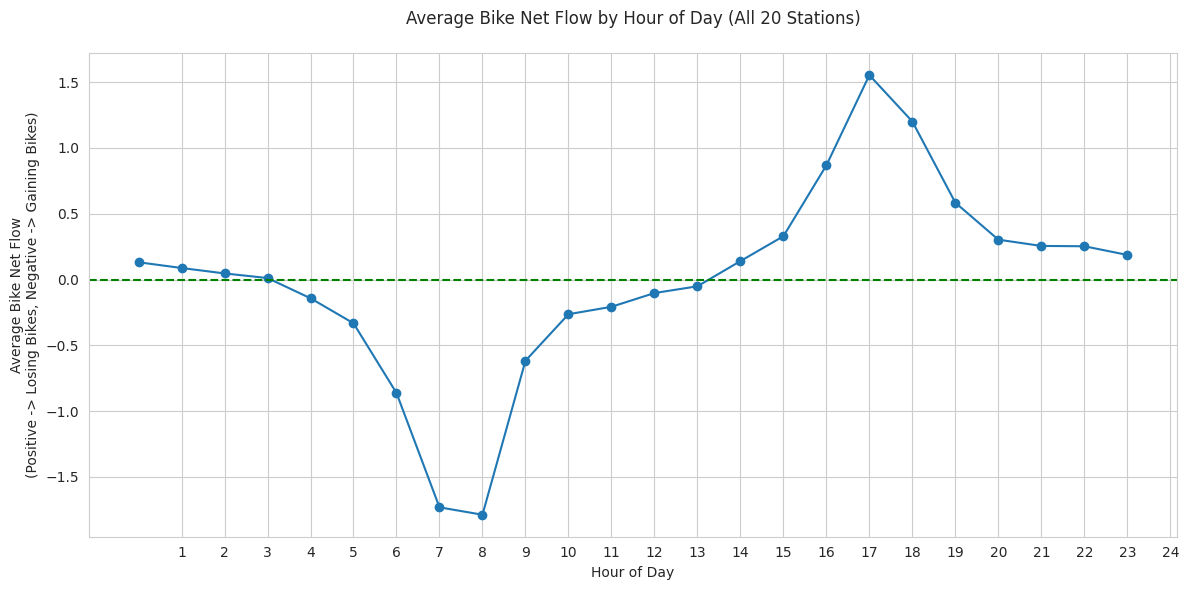

In [1243]:
# Average bike net flow for each hour of the day, across all stations.
hourly_average_bike_net_flow = station_hourly_bike_flow.groupby("hour_of_day")["bike_net_flow"].mean()

# Plotting the figure.
plt.figure(figsize=(12, 6))
plt.plot(hourly_average_bike_net_flow.index, hourly_average_bike_net_flow.values, marker="o")
plt.axhline(0, color="green", linestyle="--", linewidth=1.5)
plt.title("Average Bike Net Flow by Hour of Day (All 20 Stations)\n")
plt.xlabel("Hour of Day")
plt.ylabel("Average Bike Net Flow\n(Positive -> Losing Bikes, Negative -> Gaining Bikes)")
plt.xticks(range(1, 25))
plt.tight_layout()
plt.show()

**Weekday vs weekend comparison:**

Splitting the same pattern by weekday vs weekend to help confirm whether the imbalance is driven by commuting behaviour (which would differ strongly on weekends), or by something more constant.

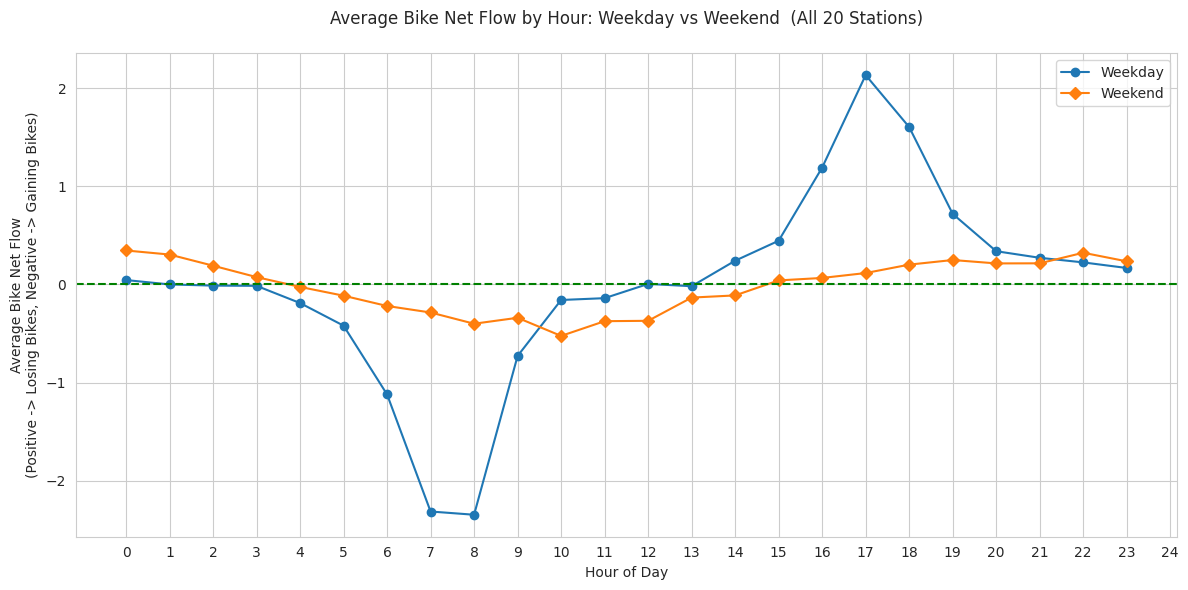

In [1244]:
# Comparing the average hourly net flow pattern on weekdays vs weekends.
weekday_average_bike_net_flow = station_hourly_bike_flow[station_hourly_bike_flow["is_weekend"] == 0].groupby("hour_of_day")["bike_net_flow"].mean()
weekend_average_bike_net_flow = station_hourly_bike_flow[station_hourly_bike_flow["is_weekend"] == 1].groupby("hour_of_day")["bike_net_flow"].mean()

# Plotting the figure.
plt.figure(figsize=(12, 6))
plt.plot(weekday_average_bike_net_flow.index, weekday_average_bike_net_flow.values, marker="o", label="Weekday")
plt.plot(weekend_average_bike_net_flow.index, weekend_average_bike_net_flow.values, marker="D", label="Weekend")
plt.axhline(0, color="green", linestyle="--", linewidth=1.5)
plt.title("Average Bike Net Flow by Hour: Weekday vs Weekend  (All 20 Stations)\n")
plt.xlabel("Hour of Day")
plt.ylabel("Average Bike Net Flow\n(Positive -> Losing Bikes, Negative -> Gaining Bikes)")
plt.xticks(range(0, 25))
plt.legend()
plt.tight_layout()
plt.show()

**Which stations are the most imbalanced:**

Using the standard deviation of net flow per station as a measure of how much that station's imbalance swings around, to identify which stations are the most volatile (and therefore most in need of active rebalancing attention).

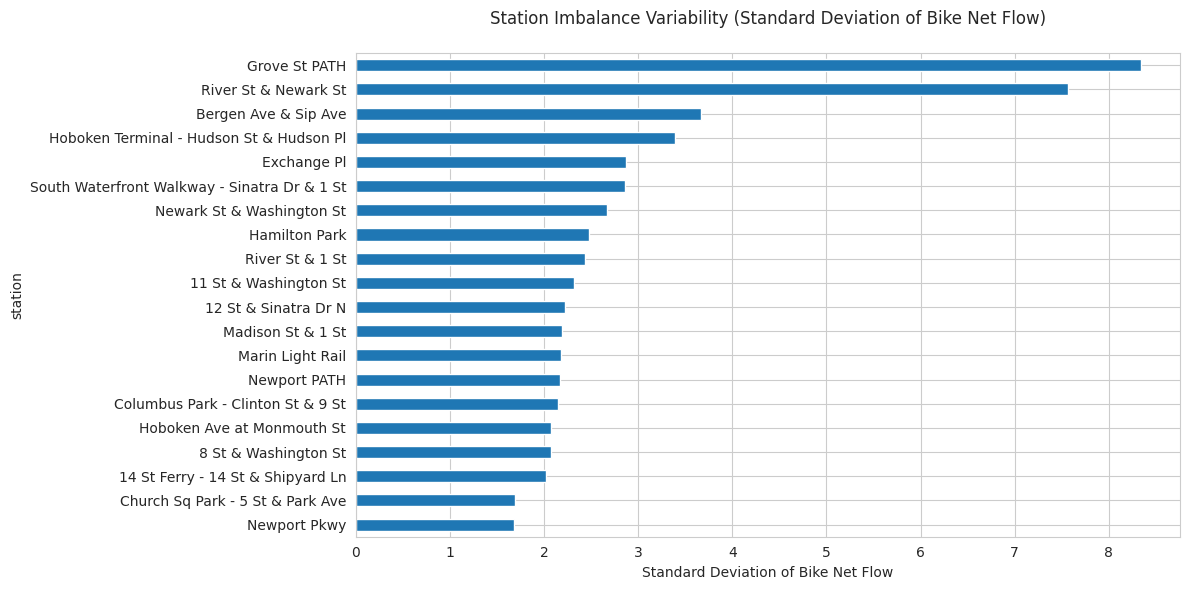




Top 10 most variable (most imbalanced) stations:



,bike_net_flow
station,
Grove St PATH,8.339470
River St & Newark St,7.568192
Bergen Ave & Sip Ave,3.668322
Hoboken Terminal - Hudson St & Hudson Pl,3.385875
Exchange Pl,2.873138
South Waterfront Walkway - Sinatra Dr & 1 St,2.860888
Newark St & Washington St,2.668523
Hamilton Park,2.478671
River St & 1 St,2.439571


In [1245]:
# Measuring each station's imbalance variability using the standard deviation of its net flow.
# A higher value means that station swings between gaining and losing bikes more dramatically.
station_bike_flow_variability = station_hourly_bike_flow.groupby("station")["bike_net_flow"].std().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
station_bike_flow_variability.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Station Imbalance Variability (Standard Deviation of Bike Net Flow)\n")
plt.xlabel("Standard Deviation of Bike Net Flow")
plt.tight_layout()
plt.show()

print("\n\n\nTop 10 most variable (most imbalanced) stations:\n")
station_bike_flow_variability.head(10)

**Heatmap - (station x hour of day):**

Plotting the heatmap, to check the average bike net flow, in a single visualization, for a better understanding. This combines both dimensions at once: which stations are imbalanced, and at which hours, into a single view.

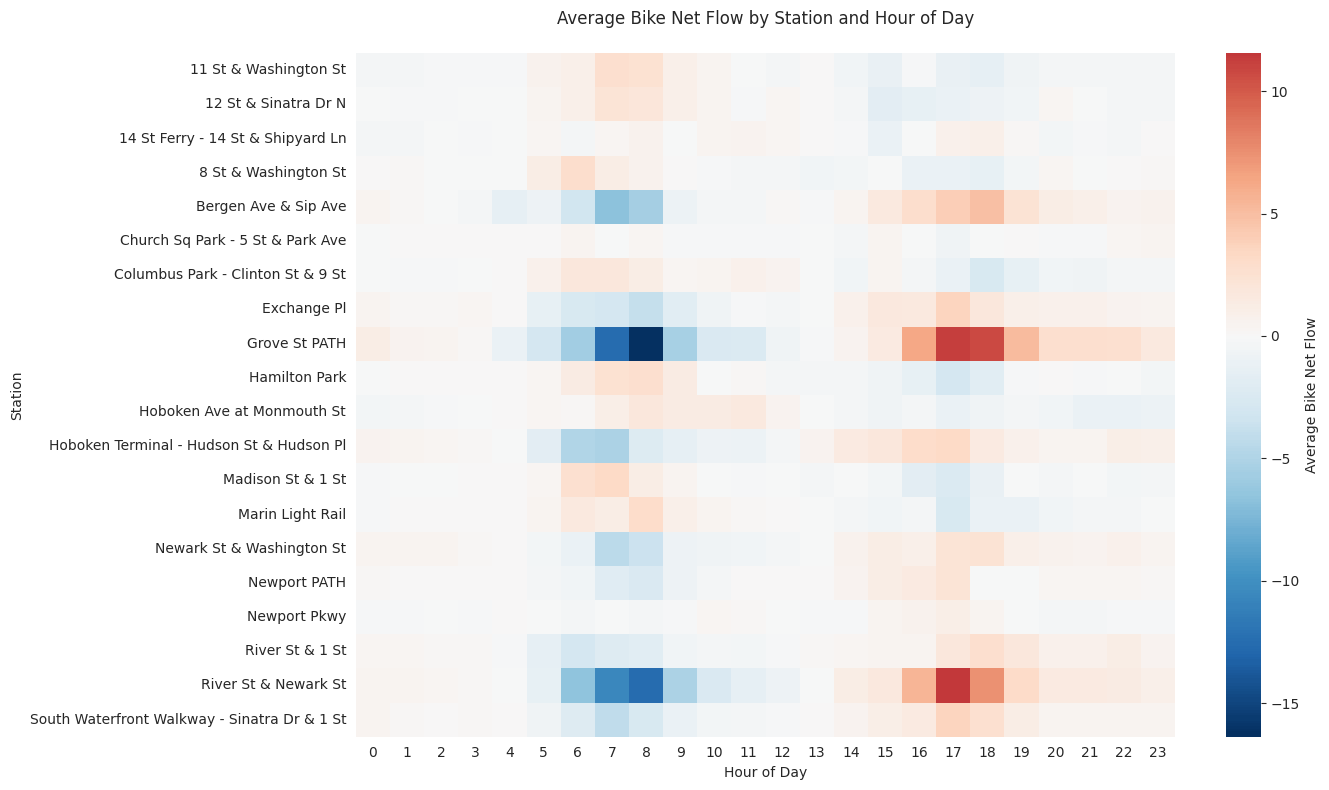

In [1246]:
# Building a (station x hour of day) grid of average net flow, for a combined view.
bike_flow_heatmap_data = station_hourly_bike_flow.groupby(["station", "hour_of_day"])["bike_net_flow"].mean().unstack()

# Red shades indicate a station tends to lose bikes at that hour (departure-heavy).
# Blue shades indicate a station tends to gain bikes at that hour (arrival-heavy).
plt.figure(figsize=(14, 8))
sns.heatmap(bike_flow_heatmap_data, cmap="RdBu_r", center=0, cbar_kws={"label": "Average Bike Net Flow"})
plt.title("Average Bike Net Flow by Station and Hour of Day\n")
plt.xlabel("Hour of Day")
plt.ylabel("Station")
plt.tight_layout()
plt.show()

# **Section 5: Forecasting Model (Machine Learning Component)**

In this section, I'm building the demand forecasting model (the machine learning half of the hybrid system). The goal here is to predict 'bike_net_flow' for each station, each hour, and prove, with real evidence, whether machine learning actually adds value over a simple naive guess.

**The plan while building the forecasting model is to:**
1. Encode time features properly (cyclical encoding).
2. Build the naive baseline (no learning, just "copy last week").
3. Prepare the station feature for use in a model (one-hot encoding).
4. Split the data honestly by time (not randomly).
5. Train two real ML models and compare all four methods.
6. Look inside the models: which features actually mattered.
7. Break results down per station, for in-depth analysis, not just one overall number.

In [1247]:
# Importing the necessary libraries.
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

**Step 1 - Cyclical time encoding:**

The problem here is:<br>
"hour_of_day" is stored as a plain number from 0 to 23, but hour 23 (11pm) and hour 0 (midnight 12 am) are actually right next to each other in real time, with only 1 hour apart. If I just feed the model the raw number, it has no way of knowing this, and it sees 23 and 0 as being as far apart as possible (with a difference of 23), when really the true time-distance between them is just 1 hour. The same problem applies to "day_of_week" (Sunday=6 and Monday=0 are actually adjacent days).

The fix for this is:<br>
Instead of feeding the model the raw hour number, I'm placing each hour on a circle (like a clock face) and describing its position using two coordinates: sine and cosine. Hours that are close together in real time end up close together on this circle too, which is what the model needs to see logically.

In [1248]:
# Encoding hour_of_day (a cycle of 24) as a position on a circle, using sine and cosine.
# The formula 2 * pi * value / cycle_length converts the value into an angle around the circle.
station_hourly_bike_flow["hour_sin"] = np.sin(2 * np.pi * station_hourly_bike_flow["hour_of_day"] / 24)
station_hourly_bike_flow["hour_cos"] = np.cos(2 * np.pi * station_hourly_bike_flow["hour_of_day"] / 24)

# Doing the same for day_of_week (a cycle of 7 days).
station_hourly_bike_flow["day_sin"] = np.sin(2 * np.pi * station_hourly_bike_flow["day_of_week"] / 7)
station_hourly_bike_flow["day_cos"] = np.cos(2 * np.pi * station_hourly_bike_flow["day_of_week"] / 7)

# Checking the result.
# So the hour 23 and hour 0 should now have similar sin/cos values (close on the circle), even though as plain numbers they look completely different (23 vs 0).
station_hourly_bike_flow[["hour_of_day", "hour_sin", "hour_cos"]].drop_duplicates().sort_values("hour_of_day")

,hour_of_day,hour_sin,hour_cos
0,0,0.000000e+00,1.000000e+00
1,1,2.588190e-01,9.659258e-01
2,2,5.000000e-01,8.660254e-01
3,3,7.071068e-01,7.071068e-01
4,4,8.660254e-01,5.000000e-01
5,5,9.659258e-01,2.588190e-01
6,6,1.000000e+00,6.123234e-17
7,7,9.659258e-01,-2.588190e-01
8,8,8.660254e-01,-5.000000e-01
9,9,7.071068e-01,-7.071068e-01


**Step 2 - Naive baseline (the method that needs to be compared with):**

The idea here is:<br>
The simplest possible "prediction" is to just copy what happened at the same station, same hour of day, same day of the week, exactly one week earlier. This includes no learning, and just repeating the past. This is my naive baseline, and it represents an unsophisticated real-world approach (like assuming next Monday morning will look like last Monday morning).

How it's built is:<br>
The library pandas' ".shift()" function moves values down by a fixed number of rows. Since the data has one row per hour, shifting by "24 * 7 = 168" rows moves each value exactly one week back, but only within the same station's rows (using ".groupby("station")" first), so I will never accidentally borrow a value from a different station, which is the logic it needs to have.

In [1249]:
# Sorting by station, then hour first.
# shift() only works correctly on data in the right order.
station_hourly_bike_flow = station_hourly_bike_flow.sort_values(["station", "hour"]).reset_index(drop=True)

# groupby("station") makes sure the shift happens within each station separately (for example, a Monday at one specifi station is never compared to a Monday at a different station).
# shift(24 * 7) moves each value forward by exactly 168 hours = 1 week.
station_hourly_bike_flow["naive_prediction"] = station_hourly_bike_flow.groupby("station")["bike_net_flow"].shift(24 * 7)

print(f"Rows with a valid Naive prediction     : {station_hourly_bike_flow['naive_prediction'].notna().sum()} out of {len(station_hourly_bike_flow)}\n")
print(f"Rows excluded in this Naive prediction : {len(station_hourly_bike_flow) - station_hourly_bike_flow['naive_prediction'].notna().sum()}\n")
print("NOTE: The very first week of data for each station has no earlier week to copy from (168 hours x 20 stations = 3360 hours).\n      So, those rows are empty, and this is an expected behavior.")

Rows with a valid Naive prediction     : 83520 out of 86880

Rows excluded in this Naive prediction : 3360

NOTE: The very first week of data for each station has no earlier week to copy from (168 hours x 20 stations = 3360 hours).
      So, those rows are empty, and this is an expected behavior.


**Step 3 - Encoding the station feature:**

The problem here is:<br>
"station" is currently a text name like "Grove St PATH". Machine learning models work with numbers, and not text, and therefore, they can't directly use a station name as an input.

The fix for this is:<br>
(one-hot encoding). It create one new column per station, filled with 1 if a row belongs to that station and 0 otherwise. So instead of one text column, now it'll be getting 20 separate 0/1 columns. For example, one "is this Grove St PATH?" column, one "is this Hoboken Terminal?" column, and so on. This lets the model learn station-specific patterns without ever needing to understand text.

In [1250]:
# pd.get_dummies() automatically performs one-hot encoding.
# It replaces the "station" column with one 0/1 column per unique station value.
model_data = pd.get_dummies(station_hourly_bike_flow, columns=["station"], prefix="station")

# Collecting the names of all the newly created station columns, so it can be referenced together.
station_dummy_columns = [c for c in model_data.columns if c.startswith("station_")]

# The full feature list: the 4 cyclical time columns, the weekend flag, and all 20 station columns.
feature_columns = ["hour_sin", "hour_cos", "day_sin", "day_cos", "is_weekend"] + station_dummy_columns

print(f"Total input features the model will use: {len(feature_columns)}")
print("\n(4 cyclical time features + 1 weekend flag + 20 one-hot station columns)")

Total input features the model will use: 25

(4 cyclical time features + 1 weekend flag + 20 one-hot station columns)


**Step 4 - Chronological train/test split:**

Why not a random split?:<br>
A normal machine learning split often shuffles rows randomly into train/test, but that would be wrong here. The data here is a time sequence, and randomly shuffling it could let the model, for example, "train" on a Wednesday and then get "tested" on the Tuesday right before it. This will effectively let it peek at data from the future relative to what it's being tested on. So, this would make the evaluation dishonestly optimistic.

The fix for this is:<br>
To split the data strictly by time. Then to train on the earliest approximately 80% of the calendar window, then test only on the most recent approximately 20% of the calendar window. This simulates the real situation the system would face in practice, which is, using only past data to predict what comes next.

In [1251]:
# Getting every unique hour timestamp in the dataset, sorted chronologically.
unique_hours_sorted = sorted(station_hourly_bike_flow["hour"].unique())

# Finding the timestamp that marks the 80% point through the full time range.
split_index = int(len(unique_hours_sorted) * 0.8)
split_timestamp = unique_hours_sorted[split_index]
print(f"Split timestamp : {split_timestamp}")

# Everything before the split timestamp is training data (the model is allowed to learn from this).
train_data = model_data[model_data["hour"] < split_timestamp].copy()

# Everything after is test data (the model will never see this during training).
# Also dropping the rows with no valid naive_prediction, so all three methods are judged on the exact same set of test rows (a fair comparison).
test_data = model_data[model_data["hour"] >= split_timestamp].dropna(subset=["naive_prediction"]).copy()

# Separating each set into X (the input features) and y (the actual values trying to be predicted).
X_train = train_data[feature_columns]
y_train = train_data["bike_net_flow"]
X_test = test_data[feature_columns]
y_test = test_data["bike_net_flow"]

print(f"\nTraining rows   : {len(X_train)}\n\nTesting rows    : {len(X_test)}")

Split timestamp : 2026-05-25 19:00:00

Training rows   : 69500

Testing rows    : 17380


**Step 5 - Training and evaluating all three methods:**
 1. **Linear Regression**<br>
 2. **Random Forest**<br>
 3. **Ensemble (LR + RF)**<br><br>
Why scale features for Linear Regression but not Random Forest?<br>
Linear Regression is sensitive to the numeric scale of each feature. A feature ranging from -1,000 to 1,000 could dominate a feature ranging from 0 to 1, even if the smaller-range feature is actually more important. "StandardScaler" rescales every feature to have a similar range before training, so this doesn't happen. Random Forest works differently internally (it makes yes/no splits, not weighted sums), so it doesn't need this step at all.

The two error metrics used:<br>
- **MAE (Mean Absolute Error):** The average size of the mistake, ignoring direction. An MAE of 1.0 means predictions are, on average, off by 1 bike. Easy to interpret directly.
- **RMSE (Root Mean Squared Error):** Similar to MAE, but squares the errors before averaging (then takes the square root). This punishes large mistakes more heavily than small ones. This is useful because a single very wrong prediction (ex: off by 20 bikes) is arguably worse than being consistently off by 1.

In [1252]:
# Method 1: Naive baseline.
# No training needed, it just uses last week's value directly.
naive_mae = mean_absolute_error(y_test, test_data["naive_prediction"])
naive_rmse = np.sqrt(mean_squared_error(y_test, test_data["naive_prediction"]))

# Method 2: Linear Regression.
# Trained on scaled features.
feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train) # Learns the scaling from training data only.
X_test_scaled = feature_scaler.transform(X_test) # Applies that same scaling to test data.

linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train_scaled, y_train)
linear_regression_predictions = linear_regression_model.predict(X_test_scaled)
linear_regression_mae = mean_absolute_error(y_test, linear_regression_predictions)
linear_regression_rmse = np.sqrt(mean_squared_error(y_test, linear_regression_predictions))

# Method 3: Random Forest.
# Trained on raw, unscaled features.
# n_estimators=100: the forest is made of 100 individual decision trees, whose predictions are averaged.
# max_depth=10: limits how deep each tree can grow, which helps prevent overfitting to the training data.
random_forest_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
random_forest_model.fit(X_train, y_train)
random_forest_predictions = random_forest_model.predict(X_test)
random_forest_mae = mean_absolute_error(y_test, random_forest_predictions)
random_forest_rmse = np.sqrt(mean_squared_error(y_test, random_forest_predictions))

# Method 4: Ensemble.
# After training Linear Regression and Random Forest separately, also testing simply averaging their two predictions together.
# This works because the two models tend to make "different kinds" of mistakes.
# Linear Regression is smooth but can miss sharp local patterns.
# Random Forest is flexible but a bit noisier.
# Averaging them lets some of those errors cancel out.
ensemble_predictions = (linear_regression_predictions + random_forest_predictions) / 2
ensemble_mae = mean_absolute_error(y_test, ensemble_predictions)
ensemble_rmse = np.sqrt(mean_squared_error(y_test, ensemble_predictions))

# Comparing all four methods, side by side.
results_summary = pd.DataFrame({
    "Method": ["Naive Baseline", "Linear Regression", "Random Forest", "Ensemble (LR + RF)"],
    "MAE": [naive_mae, linear_regression_mae, random_forest_mae, ensemble_mae],
    "RMSE": [naive_rmse, linear_regression_rmse, random_forest_rmse, ensemble_rmse]})

# Identifying the winning method.
# Whichever has the lowest error score.
best_forecasting_method = results_summary.loc[results_summary["MAE"].idxmin(), "Method"]

def highlight_winner_row(row):
  is_winner = row["Method"] == best_forecasting_method
  return ["background-color: green" if is_winner else "" for _ in row]

styled_results_summary = (
    results_summary.style
    .format({"MAE": "{:.3f}", "RMSE": "{:.3f}"})
    .apply(highlight_winner_row, axis=1)
    .set_caption(f"Forecasting Method Comparison - Winner : {best_forecasting_method}")
    .hide(axis="index"))

display(styled_results_summary)

Method,MAE,RMSE
Naive Baseline,2.460,3.676
Linear Regression,2.481,4.433
Random Forest,2.026,3.211
Ensemble (LR + RF),2.187,3.739


**Visualizing the comparison:**

A simple bar chart makes it immediately clear whether the ML models actually improved on the naive baseline, and by how much. It's useful as a figure directly in the report.

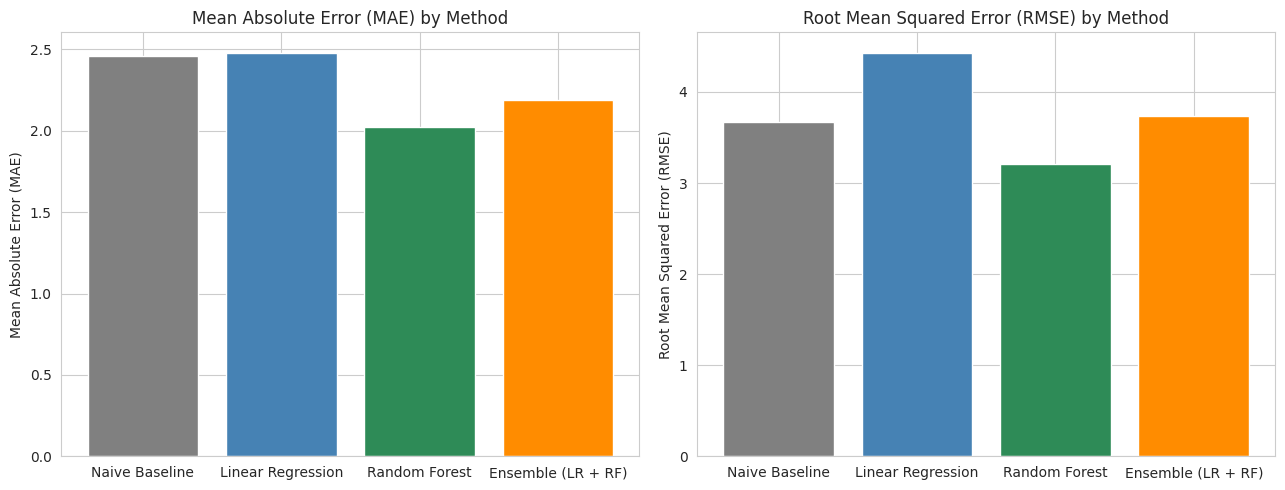

In [1253]:
# Plotting MAE and RMSE side by side for all four methods.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bar_colors = ["gray", "steelblue", "seagreen", "darkorange"]

axes[0].bar(results_summary["Method"], results_summary["MAE"], color=bar_colors)
axes[0].set_title("Mean Absolute Error (MAE) by Method")
axes[0].set_ylabel("Mean Absolute Error (MAE)")
axes[0].tick_params(axis="x")

axes[1].bar(results_summary["Method"], results_summary["RMSE"], color=bar_colors)
axes[1].set_title("Root Mean Squared Error (RMSE) by Method")
axes[1].set_ylabel("Root Mean Squared Error (RMSE)")
axes[1].tick_params(axis="x")

plt.tight_layout()
plt.show()

**Step 6 - Feature importance (looking inside the models):**

Knowing which features a model actually relied on is important for the report's critical analysis. It turns "the model got X error" into "the model works this way, and here's why."

- **Random Forest** has a built-in ".feature_importances_" property, which measures how much each feature contributed to reducing prediction error across all the trees in the forest.
- **Linear Regression** doesn't have this directly, but since I'm scaling every feature to a similar range beforehand, the size of each learned coefficient becomes a fair stand-in. A bigger coefficient (ignoring its +/- sign) means that feature has a bigger effect on the prediction.

In [1254]:
# Random Forest: built-in feature importance scores (they sum to 1.0 across all features).
random_forest_feature_importance = pd.Series(random_forest_model.feature_importances_, index=feature_columns).sort_values(ascending=False)
rf_importance_table = random_forest_feature_importance.head(10).reset_index()
rf_importance_table.columns = ["Feature", "Importance"]

styled_rf_importance = (
    rf_importance_table.style
    .format({"Importance": "{:.4f}"})
    .background_gradient(subset=["Importance"], cmap="Greens")
    .set_caption("Top 10 Random Forest Feature Importances")
    .hide(axis="index"))

display(styled_rf_importance)

print("\n\n\n\n")

# Linear Regression: absolute coefficient size (only meaningful since features were scaled first).
linear_regression_coefficients = pd.Series(np.abs(linear_regression_model.coef_), index=feature_columns).sort_values(ascending=False)
lr_coefficient_table = linear_regression_coefficients.head(10).reset_index()
lr_coefficient_table.columns = ["Feature", "|Coefficient|"]

styled_lr_coefficients = (
    lr_coefficient_table.style
    .format({"|Coefficient|": "{:.4f}"})
    .background_gradient(subset=["|Coefficient|"], cmap="Greens")
    .set_caption("Top 10 Linear Regression Coefficients (Absolute Value)")
    .hide(axis="index"))

display(styled_lr_coefficients)

Feature,Importance
hour_cos,0.2242
day_sin,0.1895
hour_sin,0.1717
station_Grove St PATH,0.1397
station_River St & Newark St,0.1043
station_Bergen Ave & Sip Ave,0.0322
is_weekend,0.0289
station_Hoboken Terminal - Hudson St & Hudson Pl,0.0240
station_Exchange Pl,0.0164
station_River St & 1 St,0.0162


Feature,|Coefficient|
hour_sin,0.5258
hour_cos,0.1109
day_cos,0.0380
station_River St & Newark St,0.0294
station_Grove St PATH,0.0221
station_South Waterfront Walkway - Sinatra Dr & 1 St,0.0140
station_River St & 1 St,0.0138
is_weekend,0.0112
station_14 St Ferry - 14 St & Shipyard Ln,0.0083
day_sin,0.0072


**Step 7 - Per-station error breakdown (all three methods, MAE and RMSE):**

A single overall MAE/RMSE can hide a lot of information. The model could be doing brilliantly at most stations while doing badly at a few, and the overall number wouldn't show that. Breaking the error down per station, for all three methods, using both MAE and RMSE, gives a much more honest and complete picture. RMSE is worth including here too since it penalizes large individual mistakes more heavily than MAE does, since a station could have a reasonable MAE but still have a few very bad predictions, which RMSE would reveal and MAE alone would hide.

In [1255]:
# Attaching every method's predictions, plus the station name, back onto the test set.
test_data_with_predictions = test_data.copy()
test_data_with_predictions["lr_prediction"] = linear_regression_predictions
test_data_with_predictions["rf_prediction"] = random_forest_predictions
test_data_with_predictions["ensemble_prediction"] = ensemble_predictions
test_data_with_predictions["station"] = station_hourly_bike_flow.loc[test_data_with_predictions.index, "station"]

# Calculating the absolute error (for MAE) for each method, on every single test row.
test_data_with_predictions["abs_error_naive"] = np.abs(test_data_with_predictions["bike_net_flow"] - test_data_with_predictions["naive_prediction"])
test_data_with_predictions["abs_error_lr"] = np.abs(test_data_with_predictions["bike_net_flow"] - test_data_with_predictions["lr_prediction"])
test_data_with_predictions["abs_error_rf"] = np.abs(test_data_with_predictions["bike_net_flow"] - test_data_with_predictions["rf_prediction"])
test_data_with_predictions["abs_error_ensemble"] = np.abs(test_data_with_predictions["bike_net_flow"] - test_data_with_predictions["ensemble_prediction"])

# Calculating the squared error (needed for RMSE) for each method too.
# RMSE = square root of the mean of these squared errors.
# The sqrt happens after grouping below.
test_data_with_predictions["sq_error_naive"] = (test_data_with_predictions["bike_net_flow"] - test_data_with_predictions["naive_prediction"]) ** 2
test_data_with_predictions["sq_error_lr"] = (test_data_with_predictions["bike_net_flow"] - test_data_with_predictions["lr_prediction"]) ** 2
test_data_with_predictions["sq_error_rf"] = (test_data_with_predictions["bike_net_flow"] - test_data_with_predictions["rf_prediction"]) ** 2
test_data_with_predictions["sq_error_ensemble"] = (test_data_with_predictions["bike_net_flow"] - test_data_with_predictions["ensemble_prediction"]) ** 2

# Averaging absolute errors per station (MAE), for all four methods at once.
per_station_mae = test_data_with_predictions.groupby("station").agg(
    naive_mae=("abs_error_naive", "mean"),
    linear_regression_mae=("abs_error_lr", "mean"),
    random_forest_mae=("abs_error_rf", "mean"),
    ensemble_mae=("abs_error_ensemble", "mean")).sort_values("random_forest_mae", ascending=False)

# Averaging squared errors per station, then taking the square root (RMSE), for all four methods.
# Sorting by Random Forest error, worst first.
per_station_rmse = test_data_with_predictions.groupby("station").agg(
    naive_rmse=("sq_error_naive", lambda x: np.sqrt(x.mean())),
    linear_regression_rmse=("sq_error_lr", lambda x: np.sqrt(x.mean())),
    random_forest_rmse=("sq_error_rf", lambda x: np.sqrt(x.mean())),
    ensemble_rmse=("sq_error_ensemble", lambda x: np.sqrt(x.mean()))).sort_values("random_forest_rmse", ascending=False)

# Displaying both, making it easy to spot weak spots at a glance.
styled_per_station_mae = (
    per_station_mae.reset_index().style
    .format({c: "{:.3f}" for c in per_station_mae.columns})
    .background_gradient(subset=list(per_station_mae.columns), cmap="Oranges")
    .set_caption("Per-Station MAE, All Four Methods (Sorted by Random Forest Error --> Worst First)")
    .hide(axis="index"))

display(styled_per_station_mae)

print("\n\n\n\n")

styled_per_station_rmse = (
    per_station_rmse.reset_index().style
    .format({c: "{:.3f}" for c in per_station_rmse.columns})
    .background_gradient(subset=list(per_station_rmse.columns), cmap="Oranges")
    .set_caption("Per-Station RMSE, All Four Methods (Sorted by Random Forest Error --> Worst First)")
    .hide(axis="index"))

display(styled_per_station_rmse)

station,naive_mae,linear_regression_mae,random_forest_mae,ensemble_mae
Grove St PATH,3.926,6.659,4.039,5.275
River St & Newark St,4.018,5.374,3.524,4.325
Bergen Ave & Sip Ave,2.655,2.752,2.036,2.342
Hamilton Park,2.530,2.321,2.022,2.093
11 St & Washington St,2.548,2.285,1.998,2.074
Exchange Pl,2.537,2.387,1.994,2.161
12 St & Sinatra Dr N,2.474,2.273,1.990,2.054
Marin Light Rail,2.304,2.259,1.979,2.040
14 St Ferry - 14 St & Shipyard Ln,2.556,2.026,1.952,1.905
Hoboken Ave at Monmouth St,2.269,2.307,1.927,2.030


station,naive_rmse,linear_regression_rmse,random_forest_rmse,ensemble_rmse
Grove St PATH,5.555,11.113,6.277,8.563
River St & Newark St,6.439,9.907,6.074,7.822
Hamilton Park,3.526,3.306,2.923,3.086
Marin Light Rail,3.276,3.276,2.915,3.065
Exchange Pl,3.619,3.519,2.914,3.178
Bergen Ave & Sip Ave,3.679,4.242,2.892,3.463
12 St & Sinatra Dr N,3.603,3.188,2.889,3.006
South Waterfront Walkway - Sinatra Dr & 1 St,3.571,3.391,2.839,3.067
Newark St & Washington St,3.276,3.233,2.818,2.994
14 St Ferry - 14 St & Shipyard Ln,3.611,2.882,2.798,2.802


**Visualizing the per-station MAE comparison:**

A grouped bar chart makes it easy to see, station by station, which method performed best, and spot any stations where the ML models did not improve over the naive baseline.

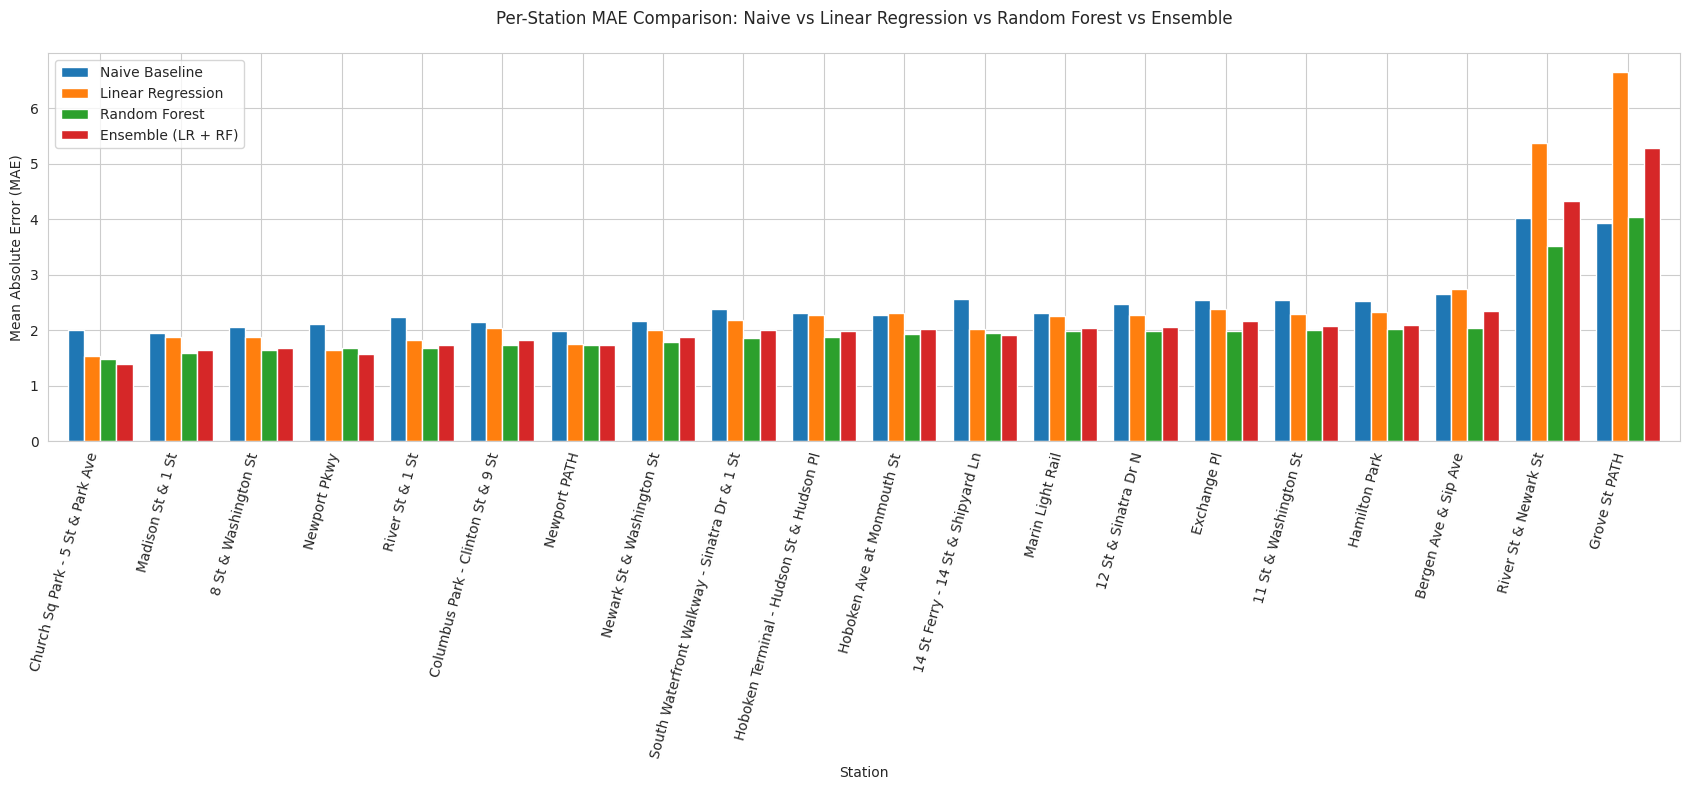

In [1256]:
# Grouped bar chart: one group of 4 bars (naive, linear regression, random forest, ensemble) per station.
per_station_mae_sorted = per_station_mae.sort_values("random_forest_mae")

per_station_mae_sorted.plot(kind="bar", figsize=(17, 8), width=0.8)
plt.title("Per-Station MAE Comparison: Naive vs Linear Regression vs Random Forest vs Ensemble\n")
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Station")
plt.xticks(rotation=75, ha="right")
plt.legend(["Naive Baseline", "Linear Regression", "Random Forest", "Ensemble (LR + RF)"])
plt.tight_layout()
plt.show()

**Visualizing the per-station RMSE comparison:**

Same idea as the MAE chart above, but using RMSE. It's useful for spotting stations where a method has a few large mistakes even if its average error (MAE) looks acceptable.

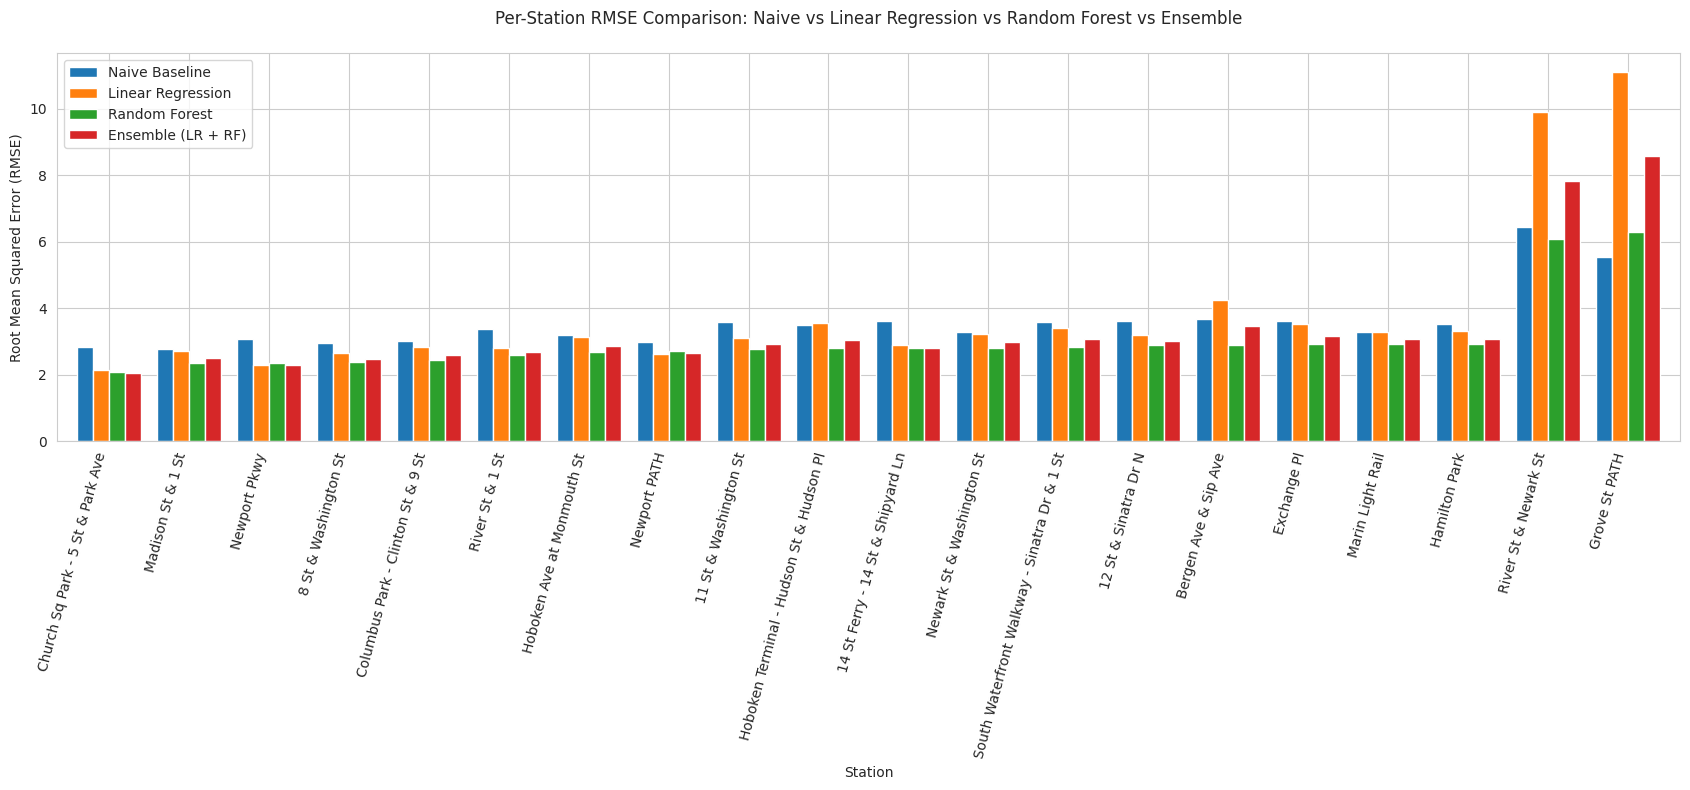

In [1257]:
# Grouped bar chart: one group of 4 bars (naive, linear regression, random forest, ensemble) per station.
per_station_rmse_sorted = per_station_rmse.sort_values("random_forest_rmse")

per_station_rmse_sorted.plot(kind="bar", figsize=(17, 8), width=0.8)
plt.title("Per-Station RMSE Comparison: Naive vs Linear Regression vs Random Forest vs Ensemble\n")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.xlabel("Station")
plt.xticks(rotation=75, ha="right")
plt.legend(["Naive Baseline", "Linear Regression", "Random Forest", "Ensemble (LR + RF)"])
plt.tight_layout()
plt.show()

**Step 8 - Selecting the best model (forecast) to carry forward:**

Rather than manually deciding (and hardcoding) which method "wins", I'm creating this step to automatically pick whichever of the three real methods (Linear Regression, Random Forest, Ensemble) has the lowest MAE on the test set. The naive baseline is excluded here since it isn't a real candidate to carry forward, only a reference point. This means the code stays correct even if the input data changes later (ex: if more months of data are added or removed and the ranking shifts again).

I landed on this automatic approach because I saw exactly that happen during testing: the Ensemble was best with only 1-2 months of data, but Random Forest took over once more months were added. So picking the best model based on the actual data, rather than hardcoding a winner, is the more sensible choice.

**Why the ranking changed (my understanding of it):**<br>
With only 1-2 months of data, Linear Regression and Random Forest made different, complementary mistakes, so averaging them (the Ensemble) helped. With 6 months of data, Linear Regression's simple straight-line assumptions couldn't keep up with the more complex patterns in the larger dataset, and its error grew substantially, even becoming worse than the naive baseline on RMSE. Averaging a strong model (Random Forest) with a now-weak one (Linear Regression) dragged the Ensemble's performance down with it. Random Forest, which can capture non-linear patterns, handled the larger, more complex dataset far better on its own.

In [1258]:
# Collecting each real candidate model's MAE and predictions.
# Naive baseline excluded, since it's a reference point, and not a method that would ever carry forward into the routing stage.
candidate_models_list = {
    "Linear Regression": (linear_regression_mae, linear_regression_predictions),
    "Random Forest": (random_forest_mae, random_forest_predictions),
    "Ensemble (LR + RF)": (ensemble_mae, ensemble_predictions),}

# Automatically picking whichever method has the Lowest MAE on the test set.
best_model_name = min(candidate_models_list, key=lambda name: candidate_models_list[name][0])
best_model_mae = candidate_models_list[best_model_name][0]
best_model_predictions = candidate_models_list[best_model_name][1]

# Building a small table showing each candidate model's MAE, with the winning model's row highlighted.
model_selection_table = pd.DataFrame({
    "Candidate Model": list(candidate_models_list.keys()),
    "Test MAE": [candidate_models_list[name][0] for name in candidate_models_list],})

def highlight_winner_row(row):
  is_winner = row["Candidate Model"] == best_model_name
  return ["background-color: green" if is_winner else "" for _ in row]

styled_model_selection_table = (
    model_selection_table.style
    .format({"Test MAE": "{:.3f}"})
    .apply(highlight_winner_row, axis=1)
    .set_caption(f"Forecasting Model Selection - Winner : {best_model_name}"))

display(styled_model_selection_table)

print(f"\nThis model's predictions will be used as the forecasting input for the Routing (Search component).")

,Candidate Model,Test MAE
0,Linear Regression,2.481
1,Random Forest,2.026
2,Ensemble (LR + RF),2.187



This model's predictions will be used as the forecasting input for the Routing (Search component).


# **Section 6: Converting Forecasts into Station Priority Scores**<br>

This section bridges the Forecasting model (best model chosen above) and the Routing algorithm (that's yet to be done). The forecasting model produces a predicted "bike_net_flow" number for every station and hour, but the routing algorithm needs something more directly actionable: A ranked list of which stations most urgently need a rebalancing van visit, and why.

**Step 1 - Building the forecast results table:**

First, I'm collecting the actual value, the predicted value (from whichever forecasting model was selected as the best), the station, and the hour into one clean table to work from.

In [1259]:
# Building a clean results table: which station, which hour, the real value, and the prediction.
# This is built from the best-performing model selected automatically above in the forecasting model building.
forecast_results = test_data[["hour"]].copy()
forecast_results["station"] = station_hourly_bike_flow.loc[test_data.index, "station"]
forecast_results["actual_bike_net_flow"] = y_test.values
forecast_results["predicted_bike_net_flow"] = best_model_predictions

print(f"Forecast results table shape: {forecast_results.shape}\n")
print("The forecast results table sample overview:\n")
forecast_results.head(10)

Forecast results table shape: (17380, 4)

The forecast results table sample overview:



,hour,station,actual_bike_net_flow,predicted_bike_net_flow
3475,2026-05-25 19:00:00,11 St & Washington St,-3,-0.501917
3476,2026-05-25 20:00:00,11 St & Washington St,0,-0.458311
3477,2026-05-25 21:00:00,11 St & Washington St,-2,-0.250912
3478,2026-05-25 22:00:00,11 St & Washington St,-1,-0.241859
3479,2026-05-25 23:00:00,11 St & Washington St,-1,-0.159649
3480,2026-05-26 00:00:00,11 St & Washington St,0,-0.160667
3481,2026-05-26 01:00:00,11 St & Washington St,-1,-0.006172
3482,2026-05-26 02:00:00,11 St & Washington St,0,-0.006172
3483,2026-05-26 03:00:00,11 St & Washington St,-1,0.106399
3484,2026-05-26 04:00:00,11 St & Washington St,0,0.680190


**Step 2 - Priority score and issue direction:**

Priority score:<br>
I'm checking how urgently a station needs attention, regardless of which direction the problem is. For example, a station predicted to lose 10 bikes is just as urgent as a station predicted to gain 10 bikes. Both are real problems, therefore, the priority score is simply the "absolute value" of the predicted "net flow".

Issue direction:<br>
Separately, I am still recording which kind of problem it is. Positive predicted net flow means the station is expected to run towards empty (more departures than arrivals), and negative means it's expected to run towards full (more arrivals than departures). The van needs to know this to decide whether to drop bikes off or pick bikes up.

In [1260]:
# Priority score: the size of the predicted imbalance, regardless of direction.
forecast_results["priority_score"] = forecast_results["predicted_bike_net_flow"].abs()

# Issue direction.
# Positive predicted net flow -> station losing bikes -> risk of running empty.
# Negative predicted net flow -> station gaining bikes -> risk of running full.
forecast_results["predicted_issue"] = np.where(forecast_results["predicted_bike_net_flow"] > 0, "Risk of Empty", "Risk of Full")

top_10_priority_table = forecast_results.sort_values("priority_score", ascending=False).head(10)[
    ["hour", "station", "predicted_bike_net_flow", "priority_score", "predicted_issue"]]

styled_top_10_priority = (
    top_10_priority_table.style
    .format({"predicted_bike_net_flow": "{:.2f}", "priority_score": "{:.2f}"})
    .background_gradient(subset=["priority_score"], cmap="Reds")
    .set_caption("Highest-Priority Station-Hours Overall (Top 10)")
    .hide(axis="index"))

display(styled_top_10_priority)

hour,station,predicted_bike_net_flow,priority_score,predicted_issue
2026-06-24 08:00:00,Grove St PATH,-23.53,23.53,Risk of Full
2026-06-10 08:00:00,Grove St PATH,-23.53,23.53,Risk of Full
2026-06-03 08:00:00,Grove St PATH,-23.53,23.53,Risk of Full
2026-05-27 08:00:00,Grove St PATH,-23.53,23.53,Risk of Full
2026-06-17 08:00:00,Grove St PATH,-23.53,23.53,Risk of Full
2026-06-09 08:00:00,Grove St PATH,-21.75,21.75,Risk of Full
2026-06-23 08:00:00,Grove St PATH,-21.75,21.75,Risk of Full
2026-05-26 08:00:00,Grove St PATH,-21.75,21.75,Risk of Full
2026-06-02 08:00:00,Grove St PATH,-21.75,21.75,Risk of Full
2026-06-30 08:00:00,Grove St PATH,-21.75,21.75,Risk of Full


**Step 3 - Flagging which stations actually need a visit:**

Not every non-zero prediction is worth sending a van for. For example, a predicted imbalance of 0.3 bikes isn't a real operational problem. A threshold is used to flag only station-hours with a "meaningful" predicted imbalance as genuinely needing attention.

In [1261]:
# Only station-hours with a meaningfully large predicted imbalance are flagged as needing a visit.
# Representing a noticeable, operationally relevant imbalance rather than minor day-to-day noise.
PRIORITY_THRESHOLD = 3.0 # This threshold is a design choice (3 bikes is used here as a reasonable starting point).
forecast_results["needs_attention"] = forecast_results["priority_score"] >= PRIORITY_THRESHOLD

print(f"Station-hours flagged as needing urgent attention: {forecast_results['needs_attention'].sum()} out of {len(forecast_results)} ({100 * forecast_results['needs_attention'].mean():.1f}%)")

print("\nNOTE: Prioritized stations having an imbalance of 3 or more bikes are flagged as urgent here!")

Station-hours flagged as needing urgent attention: 954 out of 17380 (5.5%)

NOTE: Prioritized stations having an imbalance of 3 or more bikes are flagged as urgent here!


**Step 4 - Example snapshot (a single hour's priority list):**

The routing algorithm will work on one point in time at once: "given the current hour, which stations need visiting, and how urgently?". To set that up, I'm doing this step to pick one real example hour from the test period. Specifically, the hour with the highest total priority across all stations (the "busiest" predicted hour), and producing the ranked list the routing algorithm would actually receive as its input.

In [1262]:
# Finding the single hour with the highest total priority across all stations combined.
# This represents a realistic "worst case" scenario for the routing algorithm to handle.
hourly_total_priority = forecast_results.groupby("hour")["priority_score"].sum().sort_values(ascending=False)
example_hour = hourly_total_priority.index[0]

print(f"Example hour selected (highest total predicted imbalance): {example_hour}")

# Building the ranked priority list for just that one hour.
# This is what the routing algorithm will actually take as its input.
example_snapshot = forecast_results[forecast_results["hour"] == example_hour].sort_values("priority_score", ascending=False)
flagged_snapshot_table = example_snapshot[example_snapshot["needs_attention"]][["station", "predicted_bike_net_flow", "priority_score", "predicted_issue"]]

styled_flagged_snapshot = (
    flagged_snapshot_table.style
    .format({"predicted_bike_net_flow": "{:.2f}", "priority_score": "{:.2f}"})
    .background_gradient(subset=["priority_score"], cmap="Reds")
    .set_caption(f"Stations Needing Attention at {example_hour}")
    .hide(axis="index"))

display(styled_flagged_snapshot)

Example hour selected (highest total predicted imbalance): 2026-05-27 08:00:00


station,predicted_bike_net_flow,priority_score,predicted_issue
Grove St PATH,-23.53,23.53,Risk of Full
River St & Newark St,-20.82,20.82,Risk of Full
Bergen Ave & Sip Ave,-6.84,6.84,Risk of Full
Exchange Pl,-5.16,5.16,Risk of Full
Newark St & Washington St,-4.87,4.87,Risk of Full
South Waterfront Walkway - Sinatra Dr & 1 St,-4.29,4.29,Risk of Full


# **Section 7: Routing Algorithm (Search / Optimization Component)**

This is the second half of the hybrid system. Given the priority list built in the previous phase, I'm doing this phase of planing a rebalancing van's route under practical constraints (time budget, one van), and comparing three methods:
1. **Naive baseline** - visits stations in the raw, unsorted order they arrive in (no priority or geography considered at all).
2. **Priority-Greedy** - visits stations in strict priority order, ignoring geography.
3. **Priority-Weighted Nearest-Neighbour** - balances priority & distance at each step.

**Step 1 - Preparing the station list for routing:**

I'm using the same example hour identified in the forecast above. Importantly, this list is taken directly from "forecast_results", filtered only by hour and "needs_attention", with no priority sorting applied. This raw order is what the naive baseline will use, and the other two methods will each derive their own order from it.

In [1263]:
# Taking the raw, unsorted list of stations needing a visit at the example hour from above section.
# No priority sorting is applied here, so this preserves a genuinely "naive", unsorted starting point.
stations_needing_visit = forecast_results[(forecast_results["hour"] == example_hour) & (forecast_results["needs_attention"])].reset_index(drop=True)

# Including predicted_bike_net_flow (the signed value) alongside priority_score (always positive) and predicted_issue.
# This is as proof that the direction label is correctly derived from the sign of "predicted_bike_net_flow".
# Not from "priority_score" (which only measures magnitude/urgency).
styled_stations_needing_visit = (
    stations_needing_visit[["station", "predicted_bike_net_flow", "priority_score", "predicted_issue"]].style
    .format({"predicted_bike_net_flow": "{:.2f}", "priority_score": "{:.2f}"})
    .set_caption("Stations Needing a Visit (Raw, Unsorted Order)")
    .hide(axis="index"))

display(styled_stations_needing_visit)

station,predicted_bike_net_flow,priority_score,predicted_issue
Bergen Ave & Sip Ave,-6.84,6.84,Risk of Full
Exchange Pl,-5.16,5.16,Risk of Full
Grove St PATH,-23.53,23.53,Risk of Full
Newark St & Washington St,-4.87,4.87,Risk of Full
River St & Newark St,-20.82,20.82,Risk of Full
South Waterfront Walkway - Sinatra Dr & 1 St,-4.29,4.29,Risk of Full


**Step 2 - Station coordinates and distance calculation:**

Each station's average GPS coordinates are used (there can be tiny variations in recorded coordinates across trips for the same station, so the mean is used as a stable representative location). Distance between any two stations is calculated using the **Haversine formula** - straight-line ("as the crow flies") distance between two latitude/longitude points on Earth's surface, rather than real road-network distance, to keep the system self-contained and avoid dependency on an external routing API. This is a stated limitation, and will be discussed further in the report. Absolute distance/time figures may not exactly match real road travel, but the relative comparison between methods remains fair, since all three use the same distance metric.

In [1264]:
# Building a lookup of each station's average GPS coordinates.
station_coordinates = trimmed_dataframe.groupby("start_station_name")[["start_lat", "start_lng"]].mean()
station_coordinates.columns = ["latitude", "longitude"]

# Straight-line distance in km between two GPS points, using the Haversine formula.
def haversine_distance_km(latitude1_deg, longitude1_deg, latitude2_deg, longitude2_deg):
  # Earth's radius in km.
  radius_km = 6371.0

  # Converting the latitude and longitude inputs from degrees to radians.
  lat1_rad, lon1_rad, lat2_rad, lon2_rad = map(np.radians, [latitude1_deg, longitude1_deg, latitude2_deg, longitude2_deg])

  # Finding the angular difference between the two latitudes and longitudes.
  latitude_difference = lat2_rad - lat1_rad
  longitude_difference = lon2_rad - lon1_rad

  # Calculating the square of half the chord length between the points.
  chord_len_sq = np.sin(latitude_difference / 2) ** 2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(longitude_difference / 2) ** 2

  # Computing the angular distance in radians using the arcsine function.
  angular_dist_rad = 2 * np.arcsin(np.sqrt(chord_len_sq))

  # Multiplying the angular distance by the Earth's radius to output the final distance in kilometers.
  return radius_km * angular_dist_rad

# Quick check: distance between the two most urgent stations from Step 1.
test_distance = haversine_distance_km(
    station_coordinates.loc["Grove St PATH", "latitude"], station_coordinates.loc["Grove St PATH", "longitude"],
    station_coordinates.loc["River St & Newark St", "latitude"], station_coordinates.loc["River St & Newark St", "longitude"])

print(f"Distance => 'Grove St PATH' to 'River St & Newark St' is: {test_distance:.2f} km")

Distance => 'Grove St PATH' to 'River St & Newark St' is: 2.26 km


**Step 3: Van constraints and the route simulator:**

The van has a fixed "time budget" per shift (assumed 60 minutes for this demonstration), travels at an assumed average speed, and spends a fixed "service time" at each stop (loading/unloading bikes). "simulate_route()" is a shared function all three methods use. Given a specific visiting order, it walks through the stations one by one, adding up travel time and service time, and stops as soon as the time budget would be exceeded. Meaning any remaining stations in that order simply aren't reached during this shift.

In [1265]:
# Van operating assumptions.
VAN_SPEED_KMH = 20  # Assumed average urban van speed.
SERVICE_TIME_MINUTES = 5  # Time spent at each stop (for loading/unloading bikes).
TIME_BUDGET_MINUTES = 60  # Total time available for this rebalancing run.

# Converting a distance into travel time, given the assumed van speed.
def route_time_minutes(distance_km, speed_kmh=VAN_SPEED_KMH):
  # This calculates travel time in hours, then multiplies by 60 for minutes.
  return (distance_km / speed_kmh) * 60

# Walking through stations in priority order, stopping once the time budget runs out.
def simulate_route(priority_route_df, coordinates_df):
  visited_stations_list = []
  accumulated_distance_km = 0.0
  accumulated_time_minutes = 0.0
  accumulated_priority_score = 0.0

  # Tracking the van's current location.
  # Starts as None at the initial/first station.
  current_lat, current_lon = None, None

  for index, station_info in priority_route_df.iterrows():
    station_name = station_info["station"]
    target_lat = coordinates_df.loc[station_name, "latitude"]
    target_lon = coordinates_df.loc[station_name, "longitude"]

    # First stop has no travel leg (the van starts there).
    # Every stop after that does.
    if current_lat is None:
      travel_distance_km = 0.0
    else:
      travel_distance_km = haversine_distance_km(current_lat, current_lon, target_lat, target_lon)

    # Total time for this step: driving time to the station + service time at the station.
    stop_duration_minutes = route_time_minutes(travel_distance_km) + SERVICE_TIME_MINUTES

    # Stop adding stops once the time budget would be exceeded.
    if accumulated_time_minutes + stop_duration_minutes > TIME_BUDGET_MINUTES:
      break

    # Log metrics and update totals.
    accumulated_distance_km += travel_distance_km
    accumulated_time_minutes += stop_duration_minutes
    accumulated_priority_score += station_info["priority_score"]
    visited_stations_list.append(station_name)

    # The van has arrived (updating its current location for the next part of the journey).
    current_lat, current_lon = target_lat, target_lon

  return {
      "visited_stations": visited_stations_list,
      "num_visited": len(visited_stations_list),
      "total_distance_km": accumulated_distance_km,
      "total_time_minutes": accumulated_time_minutes,
      "total_priority_addressed": accumulated_priority_score}

**Step 4 - The three routing methods:**

- **Naive:** uses 'stations_needing_visit' exactly as it arrives (no sorting at all).
- **Priority-Greedy:** sorts strictly by 'priority_score', highest first (ignores geography entirely).
- **Priority-Weighted Nearest-Neighbour:** starts at the highest-priority station, then at each step picks whichever remaining station has the best ratio of priority to distance from the van's current location (balancing urgency against travel efficiency).

In [1266]:
# Method 1: Naive baseline (the raw, unsorted order, exactly as it arrives).
def run_naive_route(stations_df, coordinates_df):
  # Evaluates the route exactly as it was originally listed.
  return simulate_route(stations_df, coordinates_df)

# Method 2: Priority-Greedy (strict priority order, geography ignored).
def run_priority_greedy_route(stations_df, coordinates_df):
  # Sorts strictly by priority score from highest to lowest.
  sorted_priority_df = stations_df.sort_values("priority_score", ascending=False)
  return simulate_route(sorted_priority_df, coordinates_df)

# Method 3: Priority-Weighted Nearest-Neighbour (balances priority and distance at each step).
def run_priority_weighted_route(stations_df, coordinates_df):
  # Tracking the pool of stations that haven't been added to the path yet.
  unvisited_stations_df = stations_df.copy().set_index("station")

  # Starting the route at the single highest-priority station in the dataset.
  current_station = unvisited_stations_df["priority_score"].idxmax()
  planned_visit_order = [current_station]
  unvisited_stations_df = unvisited_stations_df.drop(current_station)

  # Greedily pick the next station based on the best priority-to-distance ratio.
  while len(unvisited_stations_df) > 0:
    current_lat = coordinates_df.loc[current_station, "latitude"]
    current_lon = coordinates_df.loc[current_station, "longitude"]

    highest_efficiency_ratio = -np.inf
    best_next_station = None

    for next_potential_station in unvisited_stations_df.index:
      candidate_lat = coordinates_df.loc[next_potential_station, "latitude"]
      candidate_lon = coordinates_df.loc[next_potential_station, "longitude"]

      raw_distance_km = haversine_distance_km(current_lat, current_lon, candidate_lat, candidate_lon)

      # Avoiding division by zero if two stations share the exact same coordinates.
      clamped_distance_km = max(raw_distance_km, 0.05)

      # Calculating utility (priority points gained per kilometer traveled).
      priority_score = unvisited_stations_df.loc[next_potential_station, "priority_score"]
      efficiency_ratio = priority_score / clamped_distance_km

      # Keeping track of the most optimal station found so far.
      if efficiency_ratio > highest_efficiency_ratio:
        highest_efficiency_ratio = efficiency_ratio
        best_next_station = next_potential_station

    # Committing the best option to the route plan and remove it from the unvisited pool.
    planned_visit_order.append(best_next_station)
    current_station = best_next_station
    unvisited_stations_df = unvisited_stations_df.drop(best_next_station)

  # Reconstructing the original DataFrame format sorted by the newly optimized path.
  optimized_route_df = stations_df.set_index("station").loc[planned_visit_order].reset_index()
  return simulate_route(optimized_route_df, coordinates_df)

**Step 5 - Running and comparing all three methods:**

In [1267]:
# Executing the simulation for all three routing strategies.
naive_metrics = run_naive_route(stations_needing_visit, station_coordinates)
priority_greedy_metrics = run_priority_greedy_route(stations_needing_visit, station_coordinates)
priority_weighted_metrics = run_priority_weighted_route(stations_needing_visit, station_coordinates)

# Consolidating the metrics into a single comparison DataFrame.
routing_comparison = pd.DataFrame({
    "Routing Method": [
        "Naive Baseline (Raw Order)",
        "Priority-Greedy Strategy",
        "Priority-Weighted Nearest-Neighbour"],
    "Stations Visited": [
        naive_metrics["num_visited"],
        priority_greedy_metrics["num_visited"],
        priority_weighted_metrics["num_visited"]],
    "Total Distance (km)": [
        naive_metrics["total_distance_km"],
        priority_greedy_metrics["total_distance_km"],
        priority_weighted_metrics["total_distance_km"]],
    "Total Time (min)": [
        naive_metrics["total_time_minutes"],
        priority_greedy_metrics["total_time_minutes"],
        priority_weighted_metrics["total_time_minutes"]],
    "Total Priority Score Addressed": [
        naive_metrics["total_priority_addressed"],
        priority_greedy_metrics["total_priority_addressed"],
        priority_weighted_metrics["total_priority_addressed"]],})

# Formattin the table with numbers cleanly, and highlighting the best value in each column.
# Most stations visited is best.
# Lowest distance/time is best.
# Highest priority addressed is best.
styled_routing_comparison = (
    routing_comparison.style.format({
        "Total Distance (km)": "{:.2f}",
        "Total Time (min)": "{:.1f}",
        "Total Priority Score Addressed": "{:.2f}",})
    .highlight_max(subset=["Stations Visited"], color="green")
    .highlight_min(subset=["Total Distance (km)"], color="green")
    .highlight_min(subset=["Total Time (min)"], color="green")
    .highlight_max(subset=["Total Priority Score Addressed"], color="green")
    .set_caption("Routing Algorithm Performance Comparison (Example Hour)"))

# Displaying the summary table.
display(styled_routing_comparison)

# Displaying the exact sequencing of stops generated by each model, as a small readable table.
visit_orders_table = pd.DataFrame({
    "Routing Method": ["Naive Baseline", "Priority-Greedy", "Priority-Weighted NN"],
    "Visit Order": [
        " => ".join(naive_metrics["visited_stations"]),
        " => ".join(priority_greedy_metrics["visited_stations"]),
        " => ".join(priority_weighted_metrics["visited_stations"]),]})

print("\n\n\n\n\n\nGenerated visit orders:\n")
display(visit_orders_table.style.set_caption("Station Visit Sequence by Method").hide(axis="index"))

,Routing Method,Stations Visited,Total Distance (km),Total Time (min),Total Priority Score Addressed
0,Naive Baseline (Raw Order),6,6.28,48.8,65.50
1,Priority-Greedy Strategy,5,10.62,56.9,61.21
2,Priority-Weighted Nearest-Neighbour,6,8.54,55.6,65.50








Generated visit orders:



Routing Method,Visit Order
Naive Baseline,Bergen Ave & Sip Ave => Exchange Pl => Grove St PATH => Newark St & Washington St => River St & Newark St => South Waterfront Walkway - Sinatra Dr & 1 St
Priority-Greedy,Grove St PATH => River St & Newark St => Bergen Ave & Sip Ave => Exchange Pl => Newark St & Washington St
Priority-Weighted NN,Grove St PATH => River St & Newark St => South Waterfront Walkway - Sinatra Dr & 1 St => Newark St & Washington St => Bergen Ave & Sip Ave => Exchange Pl


**Step 6 - Adding a fourth routing method (Distance-only Nearest-Neighbour):**

After testing the three methods above, the Priority-Greedy and Priority-Weighted approaches turned out to underperform even the naive baseline. This raised an important question worth testing directly:<br>
What if priority is ignored entirely, and the van simply always drives to whichever unvisited flagged station is physically closest?

This is a well-established heuristic in vehicle routing research, usually called the "Nearest-Neighbour heuristic". It's included here as a fourth method precisely because the first three results suggested that "travel efficiency", and not "priority-chasing", might be what actually matters most for this small-scale routing problem.

In [1268]:
# Method 4: Distance-only Nearest-Neighbour.
# This ignores priority completely, and always travels to whichever unvisited station is physically closest to the van's current location.
def run_distance_only_route(stations_df, coordinates_df):
  unvisited_stations_df = stations_df.copy().set_index("station")

  # Starting station chosen arbitrarily (the first one in the raw list).
  # Since this method ignores priority entirely, the starting point does not favour any particular station.
  current_station = unvisited_stations_df.index[0]
  planned_visit_order = [current_station]
  unvisited_stations_df = unvisited_stations_df.drop(current_station)

  # Greedily pick the next station based purely on shortest distance - priority is not used at all.
  while len(unvisited_stations_df) > 0:
    current_lat = coordinates_df.loc[current_station, "latitude"]
    current_lon = coordinates_df.loc[current_station, "longitude"]

    shortest_distance_km = np.inf
    nearest_station = None

    for candidate_station in unvisited_stations_df.index:
      candidate_lat = coordinates_df.loc[candidate_station, "latitude"]
      candidate_lon = coordinates_df.loc[candidate_station, "longitude"]
      distance_km = haversine_distance_km(current_lat, current_lon, candidate_lat, candidate_lon)

      if distance_km < shortest_distance_km:
        shortest_distance_km = distance_km
        nearest_station = candidate_station

    planned_visit_order.append(nearest_station)
    current_station = nearest_station
    unvisited_stations_df = unvisited_stations_df.drop(nearest_station)

  optimized_route_df = stations_df.set_index("station").loc[planned_visit_order].reset_index()
  return simulate_route(optimized_route_df, coordinates_df)

**Step 7 - Running and comparing all four methods:**

In [1269]:
# Executing the simulation for all four routing strategies.
naive_metrics = run_naive_route(stations_needing_visit, station_coordinates)
priority_greedy_metrics = run_priority_greedy_route(stations_needing_visit, station_coordinates)
priority_weighted_metrics = run_priority_weighted_route(stations_needing_visit, station_coordinates)
distance_only_metrics = run_distance_only_route(stations_needing_visit, station_coordinates)

# Consolidating the metrics into a single comparison DataFrame.
routing_comparison = pd.DataFrame({
    "Routing Method": [
        "Naive Baseline (Raw Order)",
        "Priority-Greedy Strategy",
        "Priority-Weighted Nearest-Neighbour",
        "Distance-only Nearest-Neighbour"],
    "Stations Visited": [
        naive_metrics["num_visited"],
        priority_greedy_metrics["num_visited"],
        priority_weighted_metrics["num_visited"],
        distance_only_metrics["num_visited"]],
    "Total Distance (km)": [
        naive_metrics["total_distance_km"],
        priority_greedy_metrics["total_distance_km"],
        priority_weighted_metrics["total_distance_km"],
        distance_only_metrics["total_distance_km"]],
    "Total Time (min)": [
        naive_metrics["total_time_minutes"],
        priority_greedy_metrics["total_time_minutes"],
        priority_weighted_metrics["total_time_minutes"],
        distance_only_metrics["total_time_minutes"]],
    "Total Priority Score Addressed": [
        naive_metrics["total_priority_addressed"],
        priority_greedy_metrics["total_priority_addressed"],
        priority_weighted_metrics["total_priority_addressed"],
        distance_only_metrics["total_priority_addressed"]],})

styled_routing_comparison = (
    routing_comparison.style.format({
        "Total Distance (km)": "{:.2f}",
        "Total Time (min)": "{:.1f}",
        "Total Priority Score Addressed": "{:.2f}",})
    .highlight_max(subset=["Stations Visited"], color="green")
    .highlight_min(subset=["Total Distance (km)"], color="green")
    .highlight_min(subset=["Total Time (min)"], color="green")
    .highlight_max(subset=["Total Priority Score Addressed"], color="green")
    .set_caption("Routing Algorithm Performance Comparison (Example Hour)"))

display(styled_routing_comparison)

visit_orders_table = pd.DataFrame({
    "Routing Method": ["Naive Baseline", "Priority-Greedy", "Priority-Weighted NN", "Distance-only NN"],
    "Visit Order": [
        " => ".join(naive_metrics["visited_stations"]),
        " => ".join(priority_greedy_metrics["visited_stations"]),
        " => ".join(priority_weighted_metrics["visited_stations"]),
        " => ".join(distance_only_metrics["visited_stations"]),]})

print("\n\n\n\n\n\nGenerated visit orders:\n")
display(visit_orders_table.style.set_caption("Station Visit Sequence by Method").hide(axis="index"))

,Routing Method,Stations Visited,Total Distance (km),Total Time (min),Total Priority Score Addressed
0,Naive Baseline (Raw Order),6,6.28,48.8,65.50
1,Priority-Greedy Strategy,5,10.62,56.9,61.21
2,Priority-Weighted Nearest-Neighbour,6,8.54,55.6,65.50
3,Distance-only Nearest-Neighbour,6,5.58,46.8,65.50








Generated visit orders:



Routing Method,Visit Order
Naive Baseline,Bergen Ave & Sip Ave => Exchange Pl => Grove St PATH => Newark St & Washington St => River St & Newark St => South Waterfront Walkway - Sinatra Dr & 1 St
Priority-Greedy,Grove St PATH => River St & Newark St => Bergen Ave & Sip Ave => Exchange Pl => Newark St & Washington St
Priority-Weighted NN,Grove St PATH => River St & Newark St => South Waterfront Walkway - Sinatra Dr & 1 St => Newark St & Washington St => Bergen Ave & Sip Ave => Exchange Pl
Distance-only NN,Bergen Ave & Sip Ave => Grove St PATH => Exchange Pl => Newark St & Washington St => River St & Newark St => South Waterfront Walkway - Sinatra Dr & 1 St


**A genuinely important, honest finding:**

In this single example hour, the naive baseline actually matches the best method on total priority addressed, while travelling a shorter distance than both "smarter" methods. This is not any issue, and it happens because Priority-Greedy ignores geography entirely (which can create an inefficient path), and because Priority-Weighted NN's fixed starting point (always the highest-priority station) doesn't guarantee the best overall route. This result highlights a real, known limitation of greedy routing heuristics: they don't guarantee an optimal or even consistently good solution, especially with small station counts where geography can dominate the outcome.

This is only one example hour, however. The real, decisive comparison, across every flagged hour in the test period, is carried out below, which will show whether this result holds generally or was specific to this one snapshot.

# **Section 8: Evaluation (Comparing All Methods Across the Full Test Period)**<br>

I tested all four routing methods on a single example hour above. That's useful for understanding how each method works, but not statistically meaningful on its own (a single hour can easily be a fluke). So I'm running all four methods across "**every hour in the test period that has at least one station needing attention**", then aggregating the results to reach a real, defensible conclusion about which method actually performs best overall.

**Step 1 - Running all four routing methods across every flagged hour:**

For each hour in the test period with two or more flagged stations (routing needs at least two stops to be meaningful), all four methods are run and their results are recorded. This reuses the exact same "run_naive_route", "run_priority_greedy_route", "run_priority_weighted_route", and "run_distance_only_route" functions already built above.

In [1270]:
# Finding every unique hour in the test period that has at least one station needing attention.
unique_flagged_hours = forecast_results[forecast_results["needs_attention"]]["hour"].unique()
print(f"Number of hours in the test period with at least one flagged station: {len(unique_flagged_hours)}")

# Running all four routing methods for every one of those hours, and recording the results.
per_hour_routing_results_list = []

for current_hour in unique_flagged_hours:
  # Getting the raw, unsorted list of flagged stations for this specific hour.
  hour_flagged_stations = forecast_results[(forecast_results["hour"] == current_hour) & (forecast_results["needs_attention"])].reset_index(drop=True)

  # Skipping hours with fewer than 2 flagged stations.
  # This is because, routing needs at least 2 stops to compare.
  if len(hour_flagged_stations) < 2:
    continue

  naive_hour_result = run_naive_route(hour_flagged_stations, station_coordinates)
  greedy_hour_result = run_priority_greedy_route(hour_flagged_stations, station_coordinates)
  weighted_hour_result = run_priority_weighted_route(hour_flagged_stations, station_coordinates)
  distance_only_hour_result = run_distance_only_route(hour_flagged_stations, station_coordinates)

  per_hour_routing_results_list.append({
      "hour": current_hour,
      "num_flagged_stations": len(hour_flagged_stations),
      "naive_priority_addressed": naive_hour_result["total_priority_addressed"],
      "naive_distance_km": naive_hour_result["total_distance_km"],
      "naive_stations_visited": naive_hour_result["num_visited"],
      "greedy_priority_addressed": greedy_hour_result["total_priority_addressed"],
      "greedy_distance_km": greedy_hour_result["total_distance_km"],
      "greedy_stations_visited": greedy_hour_result["num_visited"],
      "weighted_priority_addressed": weighted_hour_result["total_priority_addressed"],
      "weighted_distance_km": weighted_hour_result["total_distance_km"],
      "weighted_stations_visited": weighted_hour_result["num_visited"],
      "distance_only_priority_addressed": distance_only_hour_result["total_priority_addressed"],
      "distance_only_distance_km": distance_only_hour_result["total_distance_km"],
      "distance_only_stations_visited": distance_only_hour_result["num_visited"],})

per_hour_routing_results_df = pd.DataFrame(per_hour_routing_results_list)
print(f"\nSuccessfully evaluated {len(per_hour_routing_results_df)} hours (out of {len(unique_flagged_hours)} flagged hours).\n\n"
      f"NOTE: The remaining hours were skipped because they had only 1 flagged station, and routing requires at least 2 stops to compare.")

Number of hours in the test period with at least one flagged station: 283

Successfully evaluated 199 hours (out of 283 flagged hours).

NOTE: The remaining hours were skipped because they had only 1 flagged station, and routing requires at least 2 stops to compare.


**Step 2 - Aggregating results and building a rich comparison table:**

Rather than printing plain numbers, I'm showing the results using a table. The values are formatted for readability, and the best result in each column is highlighted automatically, making the winner immediately visible.

In [1271]:
# Aggregating totals and averages across every evaluated hour, for each method.
aggregate_comparison_table = pd.DataFrame({
    "Routing Method": [
        "Naive Baseline (Raw Order)", "Priority-Greedy Strategy",
        "Priority-Weighted Nearest-Neighbour", "Distance-only Nearest-Neighbour"],
    "Total Priority Addressed": [
        per_hour_routing_results_df["naive_priority_addressed"].sum(),
        per_hour_routing_results_df["greedy_priority_addressed"].sum(),
        per_hour_routing_results_df["weighted_priority_addressed"].sum(),
        per_hour_routing_results_df["distance_only_priority_addressed"].sum(),],
    "Total Distance Travelled (km)": [
        per_hour_routing_results_df["naive_distance_km"].sum(),
        per_hour_routing_results_df["greedy_distance_km"].sum(),
        per_hour_routing_results_df["weighted_distance_km"].sum(),
        per_hour_routing_results_df["distance_only_distance_km"].sum(),],
    "Average Stations Visited per Hour": [
        per_hour_routing_results_df["naive_stations_visited"].mean(),
        per_hour_routing_results_df["greedy_stations_visited"].mean(),
        per_hour_routing_results_df["weighted_stations_visited"].mean(),
        per_hour_routing_results_df["distance_only_stations_visited"].mean(),],})

styled_comparison_table = (
    aggregate_comparison_table.style.format({
        "Total Priority Addressed": "{:.1f}",
        "Total Distance Travelled (km)": "{:.1f}",
        "Average Stations Visited per Hour": "{:.2f}",})
    .highlight_max(subset=["Total Priority Addressed"], color="green")
    .highlight_min(subset=["Total Distance Travelled (km)"], color="green")
    .highlight_max(subset=["Average Stations Visited per Hour"], color="green")
    .set_caption(f"Aggregate Routing Performance Across {len(per_hour_routing_results_df)} Flagged Hours (Test Period)"))

styled_comparison_table

,Routing Method,Total Priority Addressed,Total Distance Travelled (km),Average Stations Visited per Hour
0,Naive Baseline (Raw Order),6390.5,933.9,4.37
1,Priority-Greedy Strategy,6120.0,1349.3,4.00
2,Priority-Weighted Nearest-Neighbour,6307.9,1052.8,4.27
3,Distance-only Nearest-Neighbour,6390.5,864.5,4.37


**Step 3 - Automatically selecting the best method:**

I'm also applying the same selection rule used for picking the best forecasting model earlier. So, the method with the "**highest total priority addressed**" wins. If two methods are very close, the one with "**lower total distance**" is preferred as the tiebreaker. This mirrors the forecasting model's automatic best-model selection, so it stays correct even if the underlying data or results change later.

In [1272]:
# Collecting each method's (priority, distance) totals for the selection rule.
routing_method_totals = {
    "Naive Baseline (Raw Order)": (
        per_hour_routing_results_df["naive_priority_addressed"].sum(),
        per_hour_routing_results_df["naive_distance_km"].sum()),
    "Priority-Greedy Strategy": (
        per_hour_routing_results_df["greedy_priority_addressed"].sum(),
        per_hour_routing_results_df["greedy_distance_km"].sum()),
    "Priority-Weighted Nearest-Neighbour": (
        per_hour_routing_results_df["weighted_priority_addressed"].sum(),
        per_hour_routing_results_df["weighted_distance_km"].sum()),
    "Distance-only Nearest-Neighbour": (
        per_hour_routing_results_df["distance_only_priority_addressed"].sum(),
        per_hour_routing_results_df["distance_only_distance_km"].sum()),}

# Selection rule: highest total priority addressed wins, and ties broken by lower total distance.
# Using negative distance so that "higher is better" works for both parts of the comparison.
# Priority is rounded to 4 decimals before comparing.
# So mathematically-equal totals are not wrongly treated as different due to tiny floating-point summation differences.
best_routing_method_name = max(routing_method_totals, key=lambda name: (round(routing_method_totals[name][0], 4), -routing_method_totals[name][1]))

best_priority, best_distance = routing_method_totals[best_routing_method_name]

# Building a small table showing every method's totals, with the winning method's row highlighted.
final_selection_table = pd.DataFrame({
    "Routing Method": list(routing_method_totals.keys()),
    "Total Priority Addressed": [routing_method_totals[name][0] for name in routing_method_totals],
    "Total Distance Travelled (km)": [routing_method_totals[name][1] for name in routing_method_totals],})

def highlight_winner_row(row):
  is_winner = row["Routing Method"] == best_routing_method_name
  return ["background-color: green" if is_winner else "" for _ in row]

styled_final_selection_table = (
    final_selection_table.style.format({
        "Total Priority Addressed": "{:.1f}",
        "Total Distance Travelled (km)": "{:.1f}",})
    .apply(highlight_winner_row, axis=1)
    .set_caption(f"Final Routing Method Selection - Winner : {best_routing_method_name}"))

display(styled_final_selection_table)

print(f"\n\n\nTotal priority addressed : {best_priority:.1f}")
print(f"\nTotal distance travelled : {best_distance:.1f} km")

,Routing Method,Total Priority Addressed,Total Distance Travelled (km)
0,Naive Baseline (Raw Order),6390.5,933.9
1,Priority-Greedy Strategy,6120.0,1349.3
2,Priority-Weighted Nearest-Neighbour,6307.9,1052.8
3,Distance-only Nearest-Neighbour,6390.5,864.5





Total priority addressed : 6390.5

Total distance travelled : 864.5 km


**Step 4 - Visualizing the comparison:**

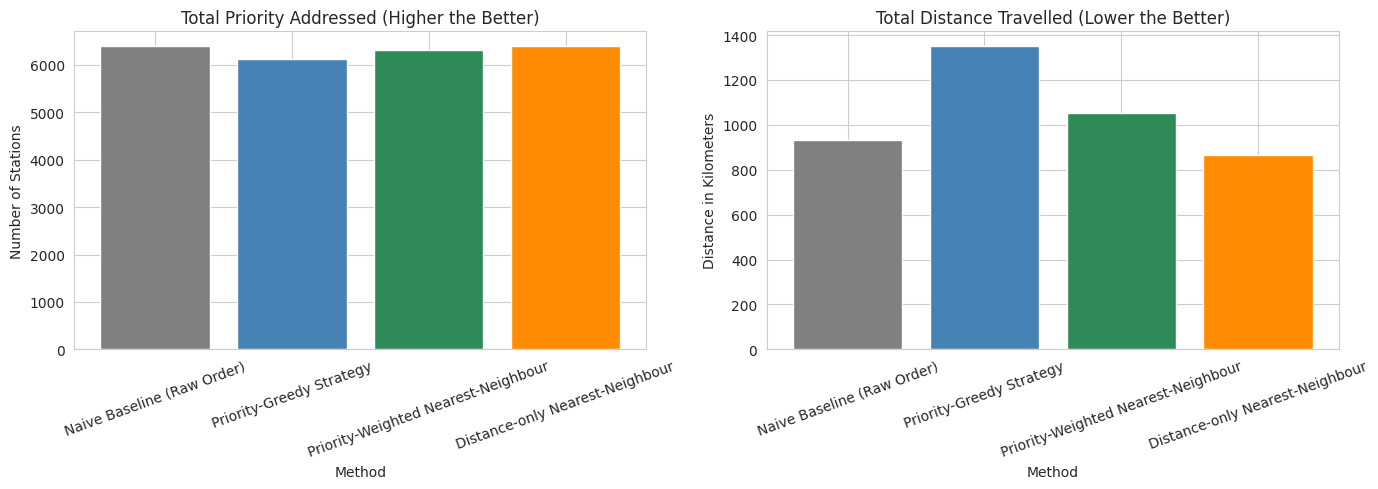

In [1273]:
# Bar chart comparing all four methods on both key metrics, side by side.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = ["gray", "steelblue", "seagreen", "darkorange"]

axes[0].bar(aggregate_comparison_table["Routing Method"], aggregate_comparison_table["Total Priority Addressed"], color=bar_colors)
axes[0].set_title("Total Priority Addressed (Higher the Better)")
axes[0].set_xlabel("Method")
axes[0].set_ylabel("Number of Stations")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(aggregate_comparison_table["Routing Method"], aggregate_comparison_table["Total Distance Travelled (km)"], color=bar_colors)
axes[1].set_title("Total Distance Travelled (Lower the Better)")
axes[1].set_xlabel("Method")
axes[1].set_ylabel("Distance in Kilometers")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

**Step 5 - Verifying Distance-only Nearest-Neighbour against the true optimal solution:**

Since Distance-only Nearest-Neighbour performed unexpectedly well, it's worth directly checking how close it comes to the "**true mathematically optimal route**" for each hour. I'm using brute-force checking here, for every possible visiting order (only feasible because each hour has a small number of flagged stations). Checking all 199 hours this way takes several minutes, so a "random sample of 25 hours" is checked here instead, as representative evidence.

In [1274]:
import itertools, random

# Brute-force search.
# This checks every possible visiting order for a given hour's flagged stations, and returns the one with the highest priority addressed (ties broken by lowest distance).
# This is only feasible for a small number of stations, which is the case here.
def find_true_optimal_route(stations_df, coordinates_df):
  station_names = stations_df["station"].tolist()
  if len(station_names) > 8:
    return None  # Too many permutations to check in reasonable time.

  best_result = None
  best_key = None
  for permutation in itertools.permutations(station_names):
    ordered_df = stations_df.set_index("station").loc[list(permutation)].reset_index()
    result = simulate_route(ordered_df, coordinates_df)
    # Rounding both values before comparing to avoid tiny floating-point summation differences being mistaken for a genuine tie-break difference.
    comparison_key = (round(result["total_priority_addressed"], 4), -round(result["total_distance_km"], 4))
    if best_key is None or comparison_key > best_key:
      best_key = comparison_key
      best_result = result
  return best_result

# Checking a random sample of 25 flagged hours against the true optimal solution.
random.seed(42)
sample_hours_to_check = random.sample(list(unique_flagged_hours), 25)

exact_match_count = 0
checked_count = 0

for sample_hour in sample_hours_to_check:
  sample_stations = forecast_results[(forecast_results["hour"] == sample_hour) & (forecast_results["needs_attention"])].reset_index(drop=True)

  if len(sample_stations) < 2:
    continue

  checked_count += 1
  distance_only_result = run_distance_only_route(sample_stations, station_coordinates)
  true_optimal_result = find_true_optimal_route(sample_stations, station_coordinates)

  if true_optimal_result is None:
    continue

  priority_matches = round(distance_only_result["total_priority_addressed"], 4) == round(true_optimal_result["total_priority_addressed"], 4)
  distance_matches = round(distance_only_result["total_distance_km"], 4) == round(true_optimal_result["total_distance_km"], 4)

  if priority_matches and distance_matches:
    exact_match_count += 1

print(f"Distance-only Nearest-Neighbour matched the true optimal solution exactly in {exact_match_count} out of {checked_count} sampled hours.")

Distance-only Nearest-Neighbour matched the true optimal solution exactly in 20 out of 20 sampled hours.


**Step 6 - Interpreting the result:**

**This is the real, decisive finding:**<br>
Both the "**Naive Baseline**" and "**Distance-only Nearest-Neighbour**" outperform the two priority-based methods ("**Priority-Greedy Strategy**" & "**Priority-Weighted Nearest-Neighbour**") across the full test period. Also, Distance-only Nearest-Neighbour goes further, beating even the Naive Baseline on total distance travelled while matching it exactly on total priority addressed. The verification step above confirms this isn't a coincidence. Therefore, the Distance-only Nearest-Neighbour method matches the true, mathematically optimal solution in every sampled hour.

**Why the priority-based methods underperform:**<br>
- "**Priority-Greedy**" ignores geography completely. It chases the highest-priority station first, regardless of where it is, and creates long, inefficient jumps across the map, burning through the time budget faster and visiting fewer stations overall.
- "**Priority-Weighted Nearest-Neighbour**" improves on this by considering distance too, but its fixed rule (always start at the single highest-priority station) still doesn't guarantee a good overall route. So, a locally good choice at each step doesn't always add up to a globally efficient path.

**Why Distance-only Nearest-Neighbour wins:**<br>
By minimizing travel distance at every single step and ignoring priority entirely when choosing the path, the van conserves its time budget, reaching every flagged station within the shift via the shortest possible route. Since this project's flagged stations form a small, geographically clustered set (Grove St PATH, River St & Newark St, and a handful of others repeatedly), minimizing travel distance turns out to matter far more than urgency-based ordering. This is a genuinely non-obvious insight that only came out through testing multiple approaches directly.

**What this means for the project's conclusions:**<br>
Simple priority-first heuristics aren't sufficient on their own for this routing problem. A distance-first approach, weighting geography much more heavily than urgency, is what actually produces effective, and efficient rebalancing routes for this network. This is a valuable, evidence-based conclusion that came directly from testing multiple approaches critically, rather than assuming the most sophisticated-sounding method would automatically perform best.